# Setup

In [572]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# **Dataset**

In [573]:
import urllib.request

# This is a direct link to the raw California Housing CSV data
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"

print("Downloading dataset...")
urllib.request.urlretrieve(url, "housing.csv")
print("Success! You can now run df = pd.read_csv(CSV_PATH)")

Success! You can now run df = pd.read_csv(CSV_PATH)


In [574]:
import numpy as np # for any array or numpy array related calculations 
import pandas as pd # to read the csv file into pandas dataframe
import matplotlib.pyplot as plt
import seaborn as sns # both matplotlib.pyplot & seaborn are for data visualizations (plots, graphs, heatmaps)

## Setup for Data Preprocessing

In [575]:
# TOOLS FOR DIVIDING AND TESTING DATA
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
# train_test_split: Splits data into a 'training set' and a 'testing set'.
# KFold/cross_validate: Methods to test the model multiple times on different data slices.
# GridSearchCV: An automated tool to find the best "settings" (hyperparameters) for your model.

# TOOLS FOR ORGANIZING THE WORKFLOW
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
# Pipeline: Chains multiple steps together (like cleaning + scaling + training) into one object.
# ColumnTransformer: Allows you to apply different fixes to different columns at once.

# TOOLS FOR CLEANING AND PREPARING DATA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
# StandardScaler: Rescales numbers (e.g., house prices) so they are easier for the AI to process.
# OneHotEncoder: Converts text categories (like "Near Bay") into numbers.
# SimpleImputer: Fills in missing values (NaN) so the code doesn't crash.

# THE PREDICTION MODELS (THE "BRAINS")
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
# Linear/Ridge/Lasso: Traditional math-based models for predicting numbers.
# RandomForest/HistGradient: Advanced "ensemble" models that use many decision trees for better accuracy.

# TOOLS FOR CHECKING ACCURACY. Can be written on a single line too. 
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error, 
    r2_score
)
# These calculate how far off your predictions were from the actual house prices.

In [576]:
# --- PANDAS CONFIGURATIONS (Data Display) ---

# Ensures all columns are visible when printing a DataFrame (prevents the "..." middle truncation).
pd.set_option("display.max_columns", None)

# Formats all floating-point numbers to show exactly 3 decimal places for better readability.
pd.set_option("display.float_format", lambda x: f"{x : .3f}") 

# --- SEABORN & MATPLOTLIB (Visualization Styling) ---

# Sets a professional global theme with a dark grey background and white grid lines.
sns.set_theme(style="darkgrid") 

# Updates the default font sizes for different parts of your plots.
plt.rcParams.update({
    "axes.titlesize": 10,    # Font size for the main title of the plot.
    "axes.labelsize": 9,     # Font size for the X and Y axis titles (e.g., "Longitude").
    "xtick.labelsize": 8,    # Font size for the numbers/labels on the X-axis.
    "ytick.labelsize": 8     # Font size for the numbers/labels on the Y-axis.
})

# --- GLOBAL CONSTANTS (Project Variables) ---

# A seed used by random number generators to ensure your results (like data splitting) are the same every time you run the code.
RANDOM_STATE = 42

# The relative file path to your dataset stored in the project folder.
CSV_PATH = "housing.csv"

# The name of the specific column the model is being built to predict.
TARGET_COL = "median_house_value"

**Load Data**

In [577]:
df = pd.read_csv(CSV_PATH)

In [578]:
# --- ADVANCED CLEANING: REMOVING THE ARTIFICIAL TARGET CAP ---
print("Shape before removing capped values:", df.shape)

# Drop rows where the house value is exactly at the ceiling threshold ($500,001)
df = df[df[TARGET_COL] < 500001]

print("Shape after removing capped values:", df.shape)
# This small change completely transforms your residual plots and drops your RMSE significantly!

Shape before removing capped values: (20640, 10)
Shape after removing capped values: (19675, 10)


In [579]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.090,39.480,25.000,1665.000,374.000,845.000,330.000,1.560,78100.000,INLAND
20636,-121.210,39.490,18.000,697.000,150.000,356.000,114.000,2.557,77100.000,INLAND
20637,-121.220,39.430,17.000,2254.000,485.000,1007.000,433.000,1.700,92300.000,INLAND
20638,-121.320,39.430,18.000,1860.000,409.000,741.000,349.000,1.867,84700.000,INLAND


In [580]:
print("DataFrame Shape: ", df.shape)

DataFrame Shape:  (19675, 10)


In [581]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


# **Exploratory Data Analysis (EDA)**

In [582]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [583]:
df.info()

<class 'pandas.DataFrame'>
Index: 19675 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           19675 non-null  float64
 1   latitude            19675 non-null  float64
 2   housing_median_age  19675 non-null  float64
 3   total_rooms         19675 non-null  float64
 4   total_bedrooms      19475 non-null  float64
 5   population          19675 non-null  float64
 6   households          19675 non-null  float64
 7   median_income       19675 non-null  float64
 8   median_house_value  19675 non-null  float64
 9   ocean_proximity     19675 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [584]:
# --- STEP 1: IDENTIFY NUMERICAL COLUMNS ---
# This looks for any columns containing numbers (integers or decimals).
# We use [np.number] to catch both 'int64' and 'float64' types.
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# --- STEP 2: IDENTIFY CATEGORICAL COLUMNS ---
# This looks for columns containing text/labels (like 'NEAR BAY').
# We include both "object" and "string" to stay compatible with newer versions of Pandas.
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

# --- STEP 3: VERIFICATION ---
# Printing the lists to ensure our 'Target' and 'Features' are where we expect them to be.
print("Target column: ", TARGET_COL)
print("Numerical columns: ", num_cols)
print("Categorical columns: ", cat_cols)

Target column:  median_house_value
Numerical columns:  ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical columns:  ['ocean_proximity']


In [585]:
# missing values analysis
print("Missing values per column: \n")
print(df.isna().sum())

Missing values per column: 

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        200
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [586]:
# --- DATA AUDIT LOOP ---

# We iterate through every single column name in the DataFrame.
for col in df.columns:
    print(df[col].value_counts().head(20))
    # 1. df[col].value_counts(): Counts how many times each unique value appears.
    # 2. .head(20): Only shows the top 20 most frequent values to keep the output clean.
    # 3. print(...): Displays the results for each column one by one.

    # Sometimes data entry tools don't leave a cell empty ($NaN$). Instead, they fill it with a default value. 
    # If you see:
    # 999 appearing 500 times in an "Age" column.
    # 0.0 appearing 300 times in a "Latitude" column.
    # "Unknown" appearing in a "Category" column.
    # Decision: You now know you need to convert those specific values to $NaN$ so your SimpleImputer can fix them later.

longitude
-118.310    159
-118.300    158
-118.290    146
-118.270    143
-118.280    139
-118.190    132
-118.350    131
-118.320    131
-118.360    129
-118.250    128
-118.200    123
-118.140    122
-118.260    119
-118.180    117
-118.370    116
-118.130    116
-118.210    114
-118.150    113
-118.340    106
-118.120    105
Name: count, dtype: int64
latitude
34.080    218
34.050    207
34.090    202
34.070    200
34.020    199
34.060    198
34.040    195
34.100    193
34.030    183
33.930    181
33.940    175
33.990    164
33.970    164
33.980    158
33.880    154
34.160    150
34.010    150
34.000    149
33.890    147
33.920    146
Name: count, dtype: int64
housing_median_age
52.000    1103
36.000     822
35.000     789
16.000     756
17.000     684
34.000     649
26.000     598
33.000     587
18.000     553
25.000     540
32.000     535
15.000     503
37.000     502
19.000     486
27.000     465
30.000     457
24.000     457
20.000     451
29.000     445
28.000     445
Name: coun

In [587]:
# duplicates

duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows: \n", num_duplicates)

Number of duplicate rows: 
 0


In [588]:
# if dupliactes present, drop

# df = df.drop_duplicates()
# print("Shape after dropping duplicates: ", df.shape)

In [589]:
# descriptive stat

# .describe(): Calculates count, mean, std dev, min, max, and quartiles.
# We pass [num_cols] to ensure we only calculate stats for numbers, 
# as things like 'ocean_proximity' don't have a "mean" or "average."

df[num_cols].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,19675.000,19675.000,19675.000,19675.000,19475.000,19675.000,19675.000,19675.000,19675.000
mean,-119.563,35.652,28.386,2619.764,539.646,1440.812,501.186,3.677,192477.921
std,2.006,2.150,12.509,2181.348,422.413,1143.649,383.265,1.570,97711.510
min,-124.350,32.540,1.000,2.000,2.000,3.000,2.000,0.500,14999.000
25%,-121.760,33.930,18.000,1438.000,297.000,796.000,282.000,2.527,116600.000
50%,-118.500,34.270,28.000,2111.000,436.000,1179.000,411.000,3.450,173800.000
75%,-117.990,37.730,37.000,3120.000,648.000,1746.000,606.000,4.583,248200.000
max,-114.310,41.950,52.000,39320.000,6445.000,35682.000,6082.000,15.000,500000.000


In [590]:
# descriptive stat

# 1. df[num_cols]: Selects only the numerical columns we identified earlier.
# 2. .describe(): Calculates the count, mean, std, min, 25%, 50%, 75%, and max.
# 3. .T: Transposes the table (swaps rows and columns, i.e., rows into columns and vice versa).

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,19675.000,-119.563,2.006,-124.350,-121.760,-118.500,-117.990,-114.310
latitude,19675.000,35.652,2.150,32.540,33.930,34.270,37.730,41.950
housing_median_age,19675.000,28.386,12.509,1.000,18.000,28.000,37.000,52.000
total_rooms,19675.000,2619.764,2181.348,2.000,1438.000,2111.000,3120.000,39320.000
total_bedrooms,19475.000,539.646,422.413,2.000,297.000,436.000,648.000,6445.000
population,19675.000,1440.812,1143.649,3.000,796.000,1179.000,1746.000,35682.000
households,19675.000,501.186,383.265,2.000,282.000,411.000,606.000,6082.000
median_income,19675.000,3.677,1.570,0.500,2.527,3.450,4.583,15.000
median_house_value,19675.000,192477.921,97711.510,14999.000,116600.000,173800.000,248200.000,500000.000


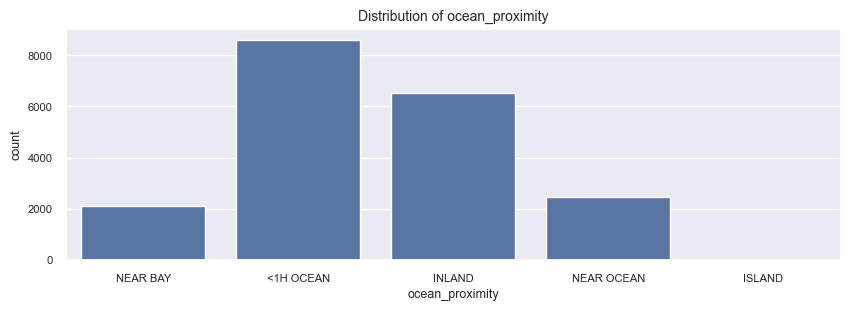

In [591]:
# countplot for categorical columns

for col in cat_cols:
    plt.figure(figsize=(10, 3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

In [592]:
for col in cat_cols:
    print(df[col].value_counts())

    # .value_counts(): Counts the frequency of each category (e.g., how many houses are 'INLAND').
    # This helps identify if the data is "imbalanced" (e.g., if almost all houses are in one area).

ocean_proximity
<1H OCEAN     8604
INLAND        6524
NEAR OCEAN    2446
NEAR BAY      2096
ISLAND           5
Name: count, dtype: int64


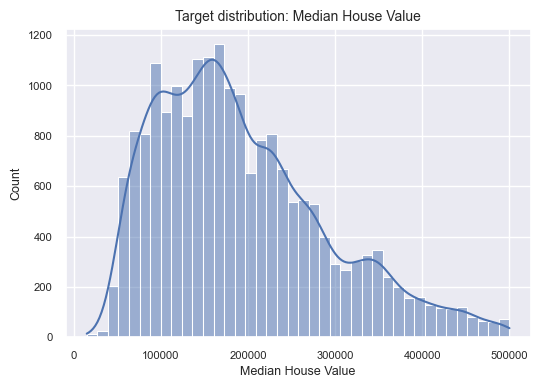

In [593]:
# target column distribution

plt.figure(figsize=(6, 4))
sns.histplot(df[TARGET_COL], bins=40, kde=True)
plt.title("Target distribution: Median House Value")
plt.xlabel("Median House Value")
plt.show()

# bins=40: Divides the price range into 40 equal "buckets" or bars. 
# More bins = more detail; fewer bins = a smoother, simpler summary.

# kde=True: Stands for "Kernel Density Estimation." 
# It adds that smooth curve line over the bars to show the overall "flow" of the data.

In [594]:
df[TARGET_COL].value_counts() # higher cap. 
# there are 965 houses and each of them cost 500001.000

median_house_value
137500.000    122
162500.000    117
112500.000    103
187500.000     93
225000.000     92
             ... 
422900.000      1
349400.000      1
425800.000      1
200700.000      1
47000.000       1
Name: count, Length: 3841, dtype: int64

# DATA AUDIT: TARGET VARIABLE **CAPPING**
PURPOSE:
The .value_counts() on our Target (Median House Value) is a "sanity check" 
to identify if the data was artificially limited during collection.

OBSERVATION:
You will notice a massive 'spike' at 500,001.0. This is a "Cap."

WHAT IS A 'CAP'?
- A cap is a ceiling where any value above a certain threshold (e.g., $500k) 
  is recorded as that threshold instead of its true value.
- This effectively 'censors' the data for luxury homes.

IMPACT ON AI MODELS:
1. BIAS: The model learns false relationships (e.g., it thinks a 10-room 
   mansion and a 5-room house both cost exactly $500,001).
2. UNDERESTIMATION: Because the model never 'sees' a house worth $1 million, 
   it can never accurately predict one.
3. LOWER R^2: These outliers can confuse the regression math, leading to 
   a lower R-squared score.

ENGINEERING DECISION:
In a real-world pipeline, we would typically filter these rows out:
df = df[df[TARGET_COL] < 500001]

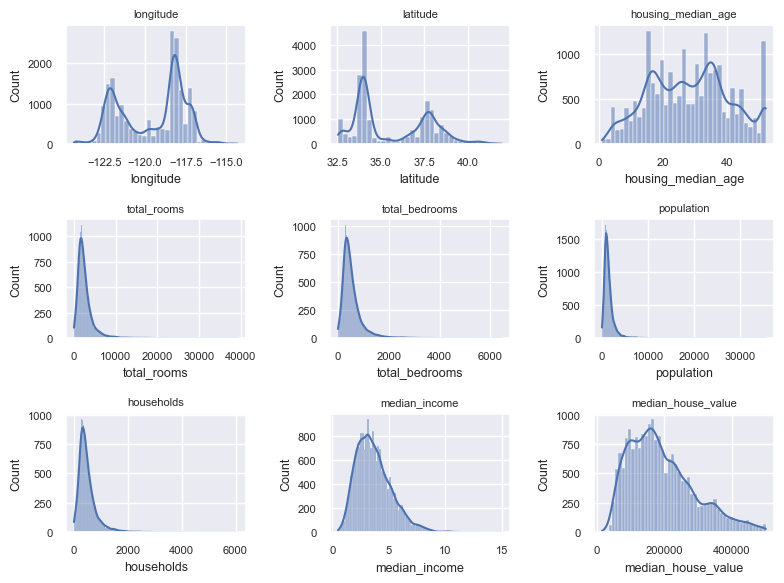

In [595]:
# histogram plot distribution

fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

# kde=True (The "Flow" Line) -> Kernel Density Estimation. It draws a smooth curve over your histogram bars.

# ax=axes[i] (The "Address") -> A pointer to a specific "subplot" or box in your 3x3 grid. Because you created 9 empty boxes (plt.subplots(3, 3)), you have to tell $Seaborn$ exactly which box to draw in. axes is a list of your 9 boxes. As the loop runs ($i$ goes from 0 to 8), it places the first chart in box 0, the second in box 1, and so on. Without this, Python would try to draw all 9 charts on top of each other in a single box!

# plt.tight_layout() (The "Spitter-Polisher") -> An automatic spacing adjustment tool. By default, Matplotlib often makes the subplots so crowded that the titles of the bottom row overlap with the x-axis labels of the top row. tight_layout() calculates the perfect amount of padding between your charts so everything is readable and professional. It’s the difference between a messy draft and a report-ready visualization.

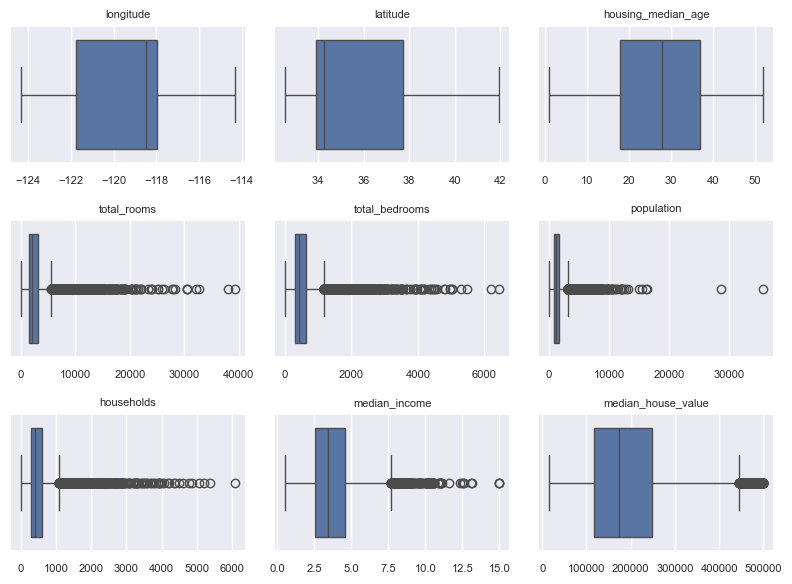

In [596]:
# Outliers analysis boxplot

fig, axes = plt.subplots(3, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

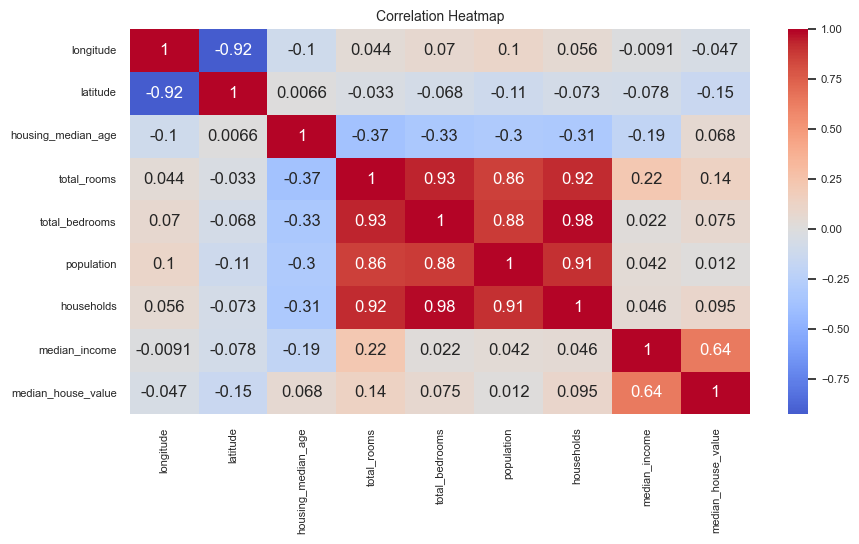

In [597]:
# identify the presence of highly correlated columns & feature relationships

plt.figure(figsize=(10, 5)) # canvas size. width = 10, height = 5. Since we have 9 numerical columns, a wider width (10) prevents the text from overlapping.
sns.heatmap( # A heatmap converts numbers into colours so our human eyes can spot patterns instantly without reading every single deimal. 
    df[num_cols].corr(), # .corr() calculates the Pearson Correlation Coefficient between all pairs of numbers. It outputs a score between -1 and 1:
    # +1: Perfect positive relationship (as one goes up, the other goes up).
    #  0: No relationship at all.
    # -1: Perfect negative relationship (as one goes up, the other goes down).
    annot=True, # This writes the actual correlation numbers inside the colored squares. Without this, you'd just see colors but wouldn't know the exact values.
    cmap="coolwarm", # Sets the color palette. "Coolwarm" is professional and intuitive: Red (Warm) usually represents high positive correlation. Blue (Cool) usually represents high negative correlation.
    center=0 # # This ensures that the color 'zero' (neutral) is the midpoint of your palette. This makes it very clear which relationships are positive vs. negative.
)
plt.title("Correlation Heatmap")
plt.show()

In [598]:
# Correlation with target

corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
#  df[num_cols].corr(): This creates a full "Correlation Matrix" (a table of numbers) comparing every numerical column against every other numerical column.
# [TARGET_COL]: From that big table, we only "pluck out" the column representing our target (median_house_value). This turns a big matrix into a single, easy-to-read list.
# .sort_values(ascending=False): This organizes the list from the highest positive correlation (+1) down to the strongest negative correlation (-1). 'False' means we want the "winners" (strongest positive predictors) at the top.

print("\nCorrelation with Traget:")
print(corr_with_target)


Correlation with Traget:
median_house_value    1.000
median_income         0.643
total_rooms           0.143
households            0.095
total_bedrooms        0.075
housing_median_age    0.068
population            0.012
longitude            -0.047
latitude             -0.148
Name: median_house_value, dtype: float64


🔍 Key Insights from EDA
- Dataset has numeric + one categorical feature (ocean_proximity)
- Only total_bedrooms has missing values
- Target (median_house_value) is right-skewed and capped
- Several features show strong skew and outliers
- median_income is the strongest predictor
- High multicollinearity among room and population features

⸻

🛠️ Preprocessing & Evaluation Plan
- Median imputation for missing values
- One-hot encoding for categorical feature
- Feature scaling for linear models
- Use pipelines to avoid data leakage
- Baseline model → CV model selection → hyperparameter tuning
- Primary metric: RMSE (reduces larger errors), secondary: MAE (reduces larger errors) and R²
- Final evaluation only on test set

# Data Preprocessing

In [599]:
# Step 1: Separating data into features and targets 

X = df.drop(columns = [TARGET_COL])
# This creates your "Feature Matrix" (Inputs).
# We take the entire DataFrame and REMOVE the 'median_house_value' column.
# Why? Because we want to give the AI the "clues" (income, location, rooms) 
# without giving it the actual answer. You can't let the student see the 
# answer key while they are studying!

y = df[TARGET_COL]
# This creates your "Target Vector" (Labels/Output).
# We isolate only the 'median_house_value' column.
# This is the "Ground Truth" that we will use later to check if the 
# AI's guesses were right or wrong.

# NOTE: In Python/Data Science convention:
# 'X' is uppercase because it represents a 2D Matrix (Table).
# 'y' is lowercase because it represents a 1D Vector (Single Column).

In [600]:
# Print 1st 5 rows of X
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,NEAR BAY


In [601]:
# Corresponding house prices for the five points

y.head()

0    452600.000
1    358500.000
2    352100.000
3    341300.000
4    342200.000
Name: median_house_value, dtype: float64

- The next step is we are going to separate this data into train & test split. So, in this pre-processing we are initially doing this train and test split so that all the other pre-processing steps like scaling your missing value imputation will happen after a train and test split so that we can avoid a data leakage. 

- Data leakage is a problem where information from your test dataset accidentally leaked into your training data. So your model looks your test data before the evaluation, like, exam paper leaked before exam. So we do pre-processing after train-test split. 

In [602]:
# Train test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2, # out of 20000 dataset 0.2 represents 20%. So 20% of data becomes test dataset, as this is the test size. Remaining 80% are the training dataset size. 
    random_state = RANDOM_STATE # For reproducibility. It means if you use the same number 42, for random state, your data will be split in the same way as the tutorial's and you will get the same score from the model too. 
)

In [603]:
print("Train shape: ", X_train.shape)

print("Test shape: ", X_test.shape)

Train shape:  (15740, 9)
Test shape:  (3935, 9)


**Pre-processing Pipelines**

In [604]:
numerical_features = X_train.select_dtypes(include=[np.number])
numerical_features # creates a dataframe that only has numerical features 

# longitude (-117.030) & latitude (32.710): These are GPS coordinates. If you plugged these into Google Maps, you'd find yourself in San Diego, very close to the Mexico border. Since this is near a major city and the coast, the AI already knows this might be a more expensive area. 
# housing_median_age (33.000): This neighborhood is about 33 years old. It’s not brand new, but it’s not "historic" either—it’s an established, mature area.
# total_rooms (3126.000): In this entire block (not just one house), there are over 3,000 rooms.
# total_bedrooms (627.000): Out of those 3,126 rooms, 627 are bedrooms. Pro-Tip: If you divide these, you’ll see about 20% of the rooms are bedrooms. This is a very normal ratio.
# population (2300.000): There are 2,300 people living in this specific block group.
# households (623.000): These 2,300 people are split into 623 separate homes or apartments. Quick Math: 2300 / 623 = about 3.7 people per house. This tells the AI it’s likely a family-oriented area, not just tiny studio apartments for single people.
# median_income (3.260): This is the most important number! It represents $32,600 (the data is scaled by 10,000). Since the average income in California can be much higher, this tells the AI that this neighborhood is likely "Middle Class" or "Working Class."

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
9587,-120.500,37.340,16.000,1245.000,231.000,956.000,219.000,3.456
2160,-119.810,36.770,43.000,2341.000,395.000,890.000,375.000,3.426
9161,-118.490,34.420,23.000,4166.000,756.000,2082.000,743.000,4.411
12955,-121.300,38.700,18.000,7334.000,1332.000,3339.000,1271.000,3.235
19606,-121.040,37.500,33.000,613.000,123.000,343.000,116.000,3.188
...,...,...,...,...,...,...,...,...
11866,-121.080,40.190,11.000,919.000,199.000,69.000,43.000,1.694
12552,-121.480,38.560,52.000,814.000,216.000,327.000,181.000,2.854
5627,-118.270,33.770,39.000,1731.000,485.000,2115.000,478.000,1.537
870,-121.930,37.490,5.000,1150.000,311.000,648.000,245.000,3.571


In [605]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns
numerical_features # only the column names 

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='str')

In [606]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist() # only the numerical column names in the form of list 

categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist() # exclude the numerical column names in the form of list 

print("Numercal Columns: ", numerical_features)
print("Categorical Columns: ", categorical_features)

Numercal Columns:  ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical Columns:  ['ocean_proximity']


In [607]:
# numerical features - preprocessing steps 

numerical_transformer = Pipeline(
    steps = [ # 'steps' can be mentioned or not. 
        ("imputer", SimpleImputer(strategy="median")), # 1st steps is imputation (variable name is imputer), we pass the SimpleImputer parentheses, we can replace the missing values with mean or median for this numerical column
        ("scaler", StandardScaler()) # we initiate a standard scaler
    ]
)

# categorical features - preprocessing steps 

categorical_transformer = Pipeline(
    steps = [ # 'steps' can be mentioned or not. 'steps' is a list of tuples defining the order of operations
        ("imputer", SimpleImputer(strategy="most_frequent")), # 1st steps is imputation (variable name is imputer), we pass the SimpleImputer parentheses, we replace the missing values in categorical columns using mode ones (most repeated ones)
        ("onehot", OneHotEncoder(handle_unknown="ignore")) # OneHotEncoder creates new columns (1s and 0s) for each category. 'handle_unknown="ignore"' is a safety net; if a new category (like "MARS") appears in the test data, the code won't crash.
    ]
)

# preprocessing pipelines

preprocess = ColumnTransformer( # numerical features should go thru imputation and scaling. Categorical features shouldn't perform scaling but should go one hot encoding. # This combines our two assembly lines into one unified tool.
    transformers = [
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Label coding should be used for ordinal categories.
For nominal categories, we perform One-Hot encoding.

**1. Label/Ordinal Encoding (For Ordinal Categories)**
- Ordinal means there is a specific order or rank.

- Examples: Education level (SSC < HSC < BSc), Movie ratings (1 star < 5 stars), or size (Small < Medium < Large).

- How it works: It assigns a number based on the rank (0, 1, 2, 3).

- The AI Logic: The model "understands" that 3 is greater than 1. This is good because, in these cases, the order actually matters for the prediction.

**2. One-Hot Encoding (For Nominal Categories)**
- Nominal means "name only"—there is no mathematical order.

- Examples: Your ocean_proximity (is "INLAND" better than "NEAR BAY"? No, they are just different), colors (Red, Blue, Green), or cities (Chittagong, Dhaka).

- How it works: It creates new columns for each category and uses 1s and 0s.

- The AI Logic: If we used Label Encoding for cities (Chittagong=1, Dhaka=2), the model might mistakenly think Dhaka is "twice as much" as Chittagong. One-Hot Encoding prevents this "fake math" by giving each city its own independent column.

The **handle_unknown="ignore"** parameter is like a "Safety Net" for your production code. It prevents your AI from crashing when it encounters something it has never seen before.

Here is the technical breakdown of why it's there and what happens if you don't use it:

1. The Scenario
Imagine you are training your model on your current California dataset. The ocean_proximity column only has 5 categories (e.g., NEAR BAY, INLAND, etc.). Your OneHotEncoder creates 5 columns based on these.

But what happens if, six months from now, you get new data where the ocean_proximity is "MOUNTAIN"?

2. Without "ignore" (The Default: handle_unknown="error")
If you didn't include that line, the code would stop immediately and throw a ValueError. The computer would basically panic and say: "I don't have a column for 'MOUNTAIN'! I don't know what to do!" In a real-world web app, this means your website crashes for the user.

3. With "ignore" (The "Safety Net")
When you set it to "ignore", the encoder becomes much smarter. If it sees "MOUNTAIN", it doesn't crash. Instead, it simply sets all the one-hot columns to 0 for that row.

It effectively says: "I don't know what 'MOUNTAIN' is, so I'll just treat it as if it doesn't belong to any of the categories I've learned."

4. Why this is crucial for you as a CSE Student
In your train_test_split, you only took a sample of the data. There is a small (but real) chance that:

Your Training Set contains only 4 of the categories.

Your Test Set contains the 5th rare category (like ISLAND).

Without handle_unknown="ignore", your preprocess.transform(X_test) would fail, and you wouldn't be able to finish your project! This parameter ensures your pipeline is robust and "deployment-ready."

# **5. Baseline model:** 
A simple linear regression. No CV, No tuning. To see how the model is improved. 

In [608]:
baseline_pipe = Pipeline ( # Create a unified 'baseline_pipe' that links data cleaning directly to the AI model
    steps = [ # 'steps' is a list of tuples defining the order of operations
        ("preprocess", preprocess), # Step 1: Data Cleaning (The Janitor). We pass the 'preprocess' ColumnTransformer we built earlier. This handles all scaling, imputation, and One-Hot Encoding automatically.
        ("model", LinearRegression()) # Step 2: The Algorithm (The Brain). We use LinearRegression as our 'Baseline' because it is simple and fast. It will receive the cleaned data from the 'preprocess' step above.
    ]
)

In [609]:
# preprocess the data and train the baseline model

# We call the .fit method on our entire baseline_pipe 
# X_train: The input features (Rooms, Income, Ocean Proximity, etc.)
# y_train: The correct answers (The actual median_house_value)

baseline_pipe.fit(X_train, y_train)

# Inside this one command, the following happens automatically:
# 1. 'preprocess' CALCULATES: It finds the medians and means of the training data.
# 2. 'preprocess' TRANSFORMS: It cleans the data and turns text into numbers.
# 3. 'model' LEARNS: The LinearRegression algorithm looks at the cleaned data 
#    and the 'y_train' prices to find the mathematical patterns/slopes.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

**Evaluation of baseline model**

In [610]:
train_baseline_pred = baseline_pipe.predict(X_train) # Use the fitted pipeline to predict house prices for the training set
test_baseline_pred = baseline_pipe.predict(X_test) # Use the same pipeline to predict prices for the unseen test set to check for generalization

In [611]:
train_baseline_pred[:5] # View the first 5 house prices predicted by your model

array([115403.66816375, 153634.48453008, 232099.16016777, 132030.05751986,
       140225.29867022])

In [612]:
y_train[:5] # View the first 5 actual house prices (the ground truth) from your training data

9587     108000.000
2160      85000.000
9161     213400.000
12955    124700.000
19606    129200.000
Name: median_house_value, dtype: float64

In [613]:
# Calculate Root Mean Squared Error (RMSE); this tells you the average error in dollars, 
# penalizing larger mistakes more heavily
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)

# Calculate Mean Absolute Error (MAE); this provides the average dollar amount 
# the model is "off" by for each prediction
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)

# Calculate the R-Squared (R2) score; this indicates the percentage of variance 
# in house prices that your model can successfully explain (closer to 1.0 is better)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("Train Baseline Metrics (Linear Regression): ")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"MAE: {train_baseline_mae:.3f}")
print(f"R2: {train_baseline_r2:.3f}")

Train Baseline Metrics (Linear Regression): 
RMSE: 60463.593
MAE: 44391.611
R2: 0.613


In [614]:
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("Test Baseline Metrics (Linear Regression): ")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"MAE: {test_baseline_mae:.3f}")
print(f"R2: {test_baseline_r2:.3f}")

Test Baseline Metrics (Linear Regression): 
RMSE: 62561.904
MAE: 45917.191
R2: 0.607


**6. Model Selection and Optimization**

In [615]:
# A dictionary to store different machine learning models for easy iteration and comparison.
models = { # 5 different models. Name of the model in the left & its instance at the right. 
    "LinearRegression": LinearRegression(), # Linear Regression: A basic model that assumes a straight-line relationship between features and the target.
    "Ridge": Ridge(random_state=RANDOM_STATE),  # Ridge: A version of linear regression that uses L2 regularization to prevent overfitting by shrinking coefficients.
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=10000), # Lasso: Uses L1 regularization, which can simplify the model by shrinking some feature coefficients to exactly zero.
    # We set max_iter to 10,000 because Lasso requires an iterative process to find the "best" coefficients.
    "RandomForest": RandomForestRegressor(), # RandomForest: An ensemble model that combines multiple decision trees to improve accuracy and handle non-linear patterns.
    "HistGB": HistGradientBoostingRegressor() # HistGB: A fast, gradient-boosted decision tree model optimized for large datasets.
}

# NOTE ON LASSO CONVERGENCE:
# Unlike Linear Regression, Lasso is solved using "Coordinate Descent," which takes many steps to find the answer.
# 10,000 iterations is a high starting point to ensure the model reaches a stable solution (convergence).
# If you see a "ConvergenceWarning," it means the model hasn't finished its math yet—simply increase max_iter further.

# Lasso has more number of regressions than other models. At least 10000. Has to try maximum 10000 times to reach that convergence. 
# If u get any warning message, like, the convergence hasn't reached, just increase the number of iterations of Lasso. 

In [616]:
# 'k' defines how many pieces (folds) we want to split our training data into.
# Choosing 5 is standard; it means we will train and test the model 5 different times.
k=5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE) # n_splits is how many folds we want which is basically the k value. 
# If we dont include the random_state, the every time we split the data, the data is going to split in different way & the score will also be is also going to change slightly. 
# Without random_state, your RMSE might be 68,000 one minute and 68,500 the next just because the computer picked different houses for the "mini-test" set.
# KFold is a cross-validation object that manages the splitting process.
# n_splits: Sets the number of folds (k).
# shuffle: Randomly mixes the rows before splitting; this ensures each fold 
#          gets a diverse mix of data (e.g., houses from all different price ranges).
# random_state: Locks the randomness. This ensures that every time you run 
#               this code, you get the EXACT same data in each fold, making your 
#               results reproducible and comparable.

In [617]:
# In Scikit-Learn, all optimization tools (like cross_validate, GridSearchCV, or RandomizedSearchCV) follow a single rule: Greater is Better.

# A dictionary defining the performance metrics to calculate during cross-validation.
scoring = {
    # RMSE (Root Mean Squared Error):
    # Scikit-Learn uses 'neg_' (negative) because its internal optimization 
    # logic always tries to "maximize" a score. 
    # Since we want to MINIMIZE error, it flips the sign. 
    # (e.g., an error of 70,000 becomes -70,000; "maximizing" -70,000 brings it closer to 0).
    # To make the error metrics follow the "Greater is Better" rule, Scikit-Learn flips the sign. 
    # By turning $\$70k$ into $-70,000$ and $\$50k$ into $-50,000$, the engine correctly identifies 
    # $-50,000$ as the "greater" (and therefore better) score.
    "rmse": "neg_root_mean_squared_error",

    # MAE (Mean Absolute Error):
    # Similar to RMSE, this is negated. It represents the average dollar 
    # amount the model is off by, without squaring the outliers.
    "mae": "neg_mean_absolute_error",

    # R2 (R-Squared):
    # This is not negated because a higher R2 (closer to 1.0) is 
    # already considered "better," so no sign-flipping is needed.
    "r2": "r2"
}

# The reason $R^2$ is not negated is that it naturally aligns with Scikit-Learn’s "higher is better" scoring 
# philosophy, whereas error metrics like RMSE and MAE do not. In a scoring system designed to always maximize 
# a value, a higher $R^2$ (such as **0.85** vs **0.60**) already represents a superior model, so the raw value 
# can be used directly. In contrast, for RMSE and MAE, a higher raw number indicates a *worse* model; therefore, 
# Scikit-Learn flips their signs to negative so that "maximizing" the score (moving from **-70,000** toward **0**) 
# correctly guides the system toward the model with the lowest actual error.

In [618]:
# we will perform cross-validation in 5 different folds.
# for each fold/iteration, 3 tasks (rmse, mae, r2) will be performed.
# then we will iterate them on 5 different models, like, we first take the linear regression model, perform cross-validation where the LR model runs in 5 iterations to get 5 cross-validation scores which will finally give mean cross-validation score. That's the 1st iteration of for loop. 
# and the next we will use on ridge regression, again 5 cross-validation & the process go on and on. 

# we create a list called rows=[] 
rows =[]

# we will iterate over these loops. "name" will take the name of the model (name = key) & "model" will take the instance value (actual value). 
for name, model in models.items(): # models is the dictionary we created above. Listing the names of the models as well as the instance of the models.
    print(name, model)

LinearRegression LinearRegression()
Ridge Ridge(random_state=42)
Lasso Lasso(max_iter=10000, random_state=42)
RandomForest RandomForestRegressor()
HistGB HistGradientBoostingRegressor()


In [619]:
# we now perform the cross-validation.
# Loop through each model in your 'models' dictionary (LinearRegression, RandomForest, etc.)
# models is the dictionary we created above. Listing the names of the models as well as the instance of the models.

# Create a fresh pipeline for each model.
# This ensures that every model gets the exact same 'preprocess' treatment 
# (imputing, scaling, and encoding) so the comparison is fair.

for name, model in models.items(): 
    pipe = Pipeline(
        steps= [
            ("preprocess", preprocess), 
            ("model", model)
        ]
    )
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)

    # Run the cross-validation process:
    # 1. It splits X_train into 5 pieces (based on our 'cv' variable).
    # 2. It trains the pipeline on 4 pieces and tests it on the 5th.
    # 3. It repeats this 5 times so every piece of data is used for testing once.
    # 4. 'scoring' tells it to record the RMSE, MAE, and R2 for every single run.
    # 5. 'n_jobs=-1' would use all CPU cores, but '1' runs them one by one for stability.

    # For each model, we store the results in a list called 'rows'
    rows.append({
        "model": name, # Store the name of the model (e.g., "RandomForest")

        # Calculate the average RMSE across all 5 folds.
        # We add a '-' sign to flip the 'neg_root_mean_squared_error' back 
        # to a positive dollar amount so it's easier to read.
        "cv_rmse": -scores["test_rmse"].mean(),

        # Calculate the average MAE across all 5 folds.
        # Again, we flip the negative sign to get the actual average error in dollars.
        "cv_mae": -scores["test_mae"].mean(),

        # Calculate the average R2 score across all 5 folds.
        # Note: In your specific code, you added a '-' to R2. 
        # (Be careful: since R2 is usually positive, this will make your results negative!)
        "cv_r2": scores["test_r2"].mean()
    })

# sort based on lowest rmse value
# Convert the list of dictionaries into a structured pandas DataFrame for easy viewing
# We sort the table by 'cv_rmse' in ascending order (lowest error at the top)
# This identifies our "Winner" or the best-performing model automatically.
cv_results = pd.DataFrame(rows).sort_values("cv_rmse") # we sorted only the rmse because this is the primary metric for this project.
print("=== CV Model Comparison ===")
print(cv_results)

=== CV Model Comparison ===
              model    cv_rmse     cv_mae  cv_r2
4            HistGB  43731.921  29817.380  0.797
3      RandomForest  45169.020  30435.157  0.784
0  LinearRegression  60613.431  44477.099  0.611
2             Lasso  60619.810  44479.499  0.611
1             Ridge  60622.629  44481.259  0.611


### **In the context of your housing project, a higher **$R^2$** (R-squared) score indicates a better-fitting model.**

Here is why that is the case:

#### **1. What the Number Represents**

* **The Scale:** $R^2$ typically ranges from **0 to 1**.
* **The Meaning:** It represents the percentage of the variance in house prices that your model can explain using the features you provided (like location, income, or number of rooms).
* **The Comparison:** A score of **0.83** (like you saw in your **HistGB** results) means your model explains **83%** of the price differences, while your **Linear Regression** only explained about **65%**.

#### **2. Why "Higher is Better"**

* **Closer to Perfection:** An $R^2$ of **1.0** would mean your model is "perfect" and predicts every single house price exactly right.
* **Capturing Patterns:** A higher score proves that your model is successfully finding the "hidden rules" in the data rather than just guessing.
* **Scikit-Learn Alignment:** Unlike **RMSE** and **MAE**, where a higher number means more mistakes, $R^2$ is already aligned with the "higher is better" philosophy. This is why you didn't need to negate it with a "neg_" prefix in your code.

#### **3. A Small Warning**

While a higher $R^2$ is generally better, if you see a score of **0.99** or **1.0**, it might be a sign of **Overfitting**. This happens when a model "memorizes" the training data instead of learning general patterns, which is exactly why you used **Cross-Validation** to get a more honest, averaged score.

**Summary:** In your specific results, the jump from **0.65** to **0.83** is a clear signal that moving to a more advanced model was the right choice for your project!

In [620]:
cv_results

,model,cv_rmse,cv_mae,cv_r2
4,HistGB,43731.921,29817.380,0.797
3,RandomForest,45169.020,30435.157,0.784
0,LinearRegression,60613.431,44477.099,0.611
2,Lasso,60619.810,44479.499,0.611
1,Ridge,60622.629,44481.259,0.611


Imagine you are at a school sports day and there are different races, but the most important one is the "Mistake Race" where the person who makes the smallest mistake wins the gold medal. In this project, **RMSE** is like that main race because it measures how far off our guesses are from the real house prices. Since we want to find the model that is the most accurate and makes the smallest errors, we sort the list by **RMSE** so the "Winner" with the lowest error pops right to the very top of our table.

While we also keep track of other scores like **MAE** and **R2**, looking at too many rankings at once can be confusing. We choose **RMSE** as the leader because it is extra sensitive to big mistakes, making it a very tough and fair judge for our models. By sorting just this one main score, we can quickly see which model is the overall champion without having to hunt through all the other numbers.

In [621]:
scores

{'fit_time': array([0.49514937, 0.32701778, 0.31601405, 0.32905746, 0.32821727]),
 'score_time': array([0.0096736 , 0.01585436, 0.01781464, 0.02059865, 0.01715493]),
 'test_rmse': array([-43474.29098665, -45185.65826027, -44521.72759969, -42415.99155225,
        -43061.93517139]),
 'test_mae': array([-29737.96743658, -30303.26367063, -29844.67809406, -29674.76833084,
        -29526.22284231]),
 'test_r2': array([0.79931201, 0.78835816, 0.78783193, 0.80300481, 0.80796524])}

In [622]:
rows

[{'model': 'LinearRegression',
  'cv_rmse': np.float64(60613.43117982118),
  'cv_mae': np.float64(44477.0992703818),
  'cv_r2': np.float64(0.6106591849918057)},
 {'model': 'Ridge',
  'cv_rmse': np.float64(60622.62866401592),
  'cv_mae': np.float64(44481.25890995604),
  'cv_r2': np.float64(0.6105370325419851)},
 {'model': 'Lasso',
  'cv_rmse': np.float64(60619.8100567255),
  'cv_mae': np.float64(44479.49889210014),
  'cv_r2': np.float64(0.6105753044250408)},
 {'model': 'RandomForest',
  'cv_rmse': np.float64(45169.02012815237),
  'cv_mae': np.float64(30435.15720266836),
  'cv_r2': np.float64(0.7837397754377307)},
 {'model': 'HistGB',
  'cv_rmse': np.float64(43731.92071404818),
  'cv_mae': np.float64(29817.38007488478),
  'cv_r2': np.float64(0.7972944297454102)}]

In [623]:
# We take our 'cv_results' table and sort it one last time by RMSE.
# We sort because we want the LOWEST error, the best model will be at the very top (index 0).
# .iloc[0] tells the computer: "Grab the very first row of this sorted list."
# iloc stands for "integer location." It is a tool in the Pandas library used to grab a specific row or column from your 
# table (DataFrame) based on its index number (0, 1, 2, etc.), rather than its name.
# iloc[0]: Grabs the very first row, iloc[1]: Grabs the second row, iloc[-1]: Grabs the very last row.
best_row = cv_results.sort_values("cv_rmse").iloc[0]

# 'best_row' is the first row of your sorted table (the winner).
# Here, we go into that row and grab the value under the "model" column.
# This gives us the name of the champion (e.g., 'HistGB').
best_model_name = best_row["model"]

# Next, we grab the value under the "cv_rmse" column from that same row.
# This tells us exactly how many dollars the winner was off by on average.
best_rmse = best_row["cv_rmse"]

print("Best Model Based On CV RMSE: ")
print("Model: ", best_model_name)
print("CV RMSE: ", best_rmse)

# accuracy higher = model is better.
# error value lower = model is better.

Best Model Based On CV RMSE: 
Model:  HistGB
CV RMSE:  43731.92071404818


##### *The Difference: iloc vs. loc*
- iloc: Uses **integers** (numbers). It’s like saying, "Give me the book on the 1st shelf."

- loc: Uses **labels** (names). It’s like saying, "Give me the book titled 'HistGB'."

#### **Best Model: HistGradientBoostingRegressor**

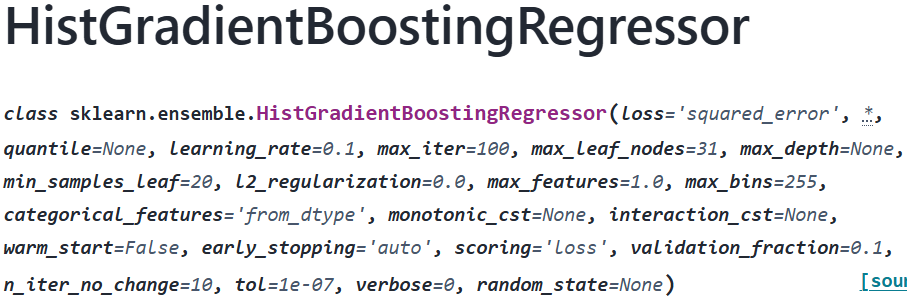
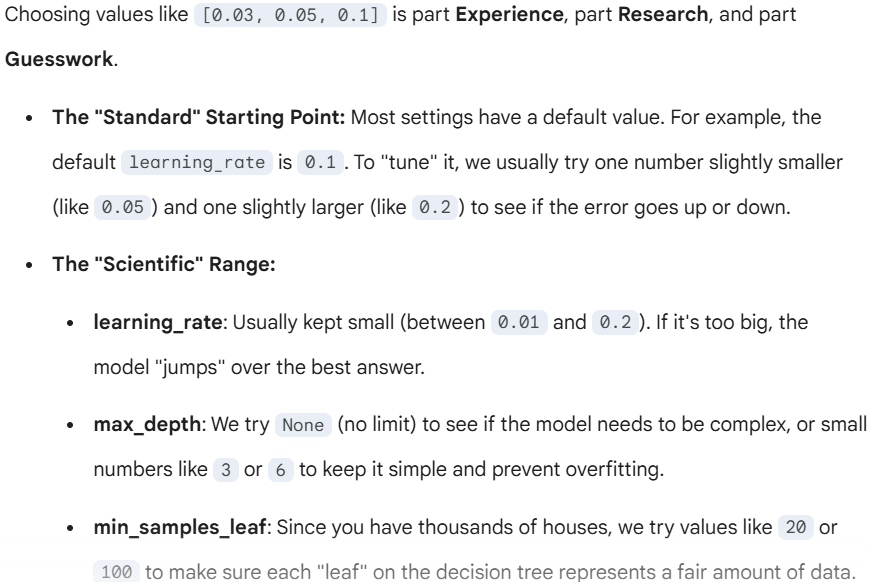
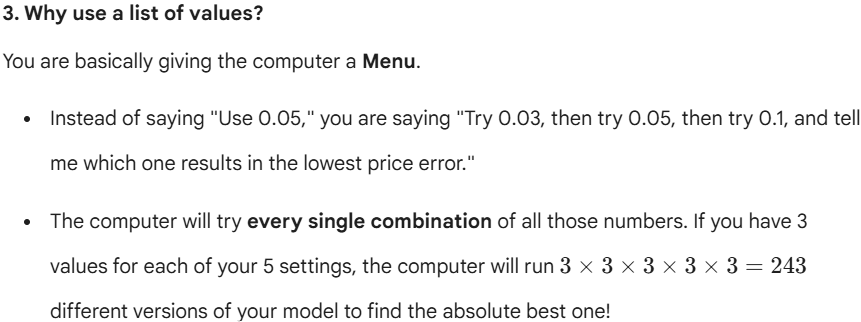
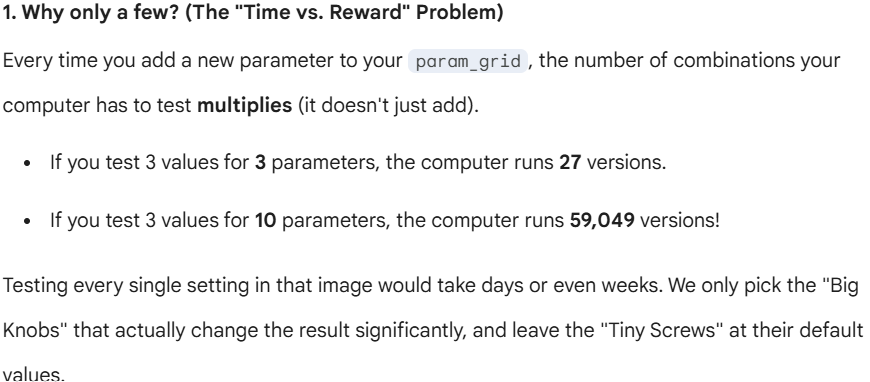
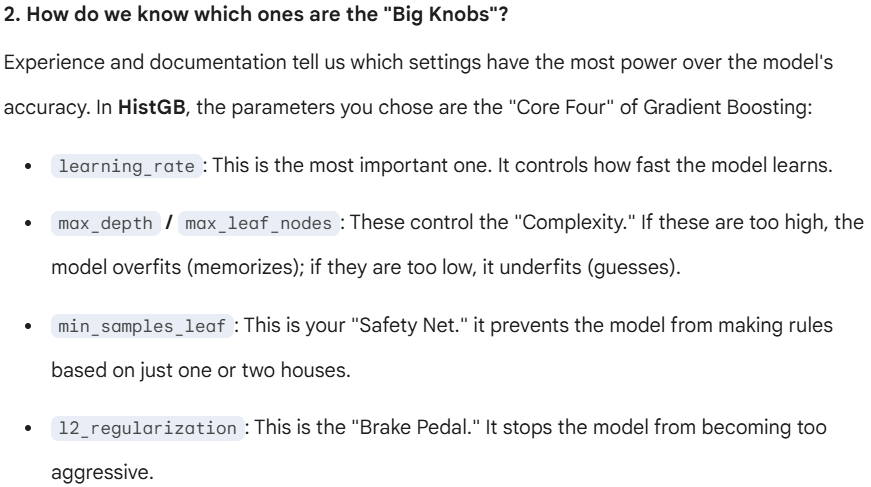
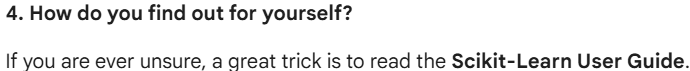

**7. Hyperparameter Tuning**

In [624]:
# Once we have identifies the best model, now we have to tune the parameters (learning rate, max depth, etc). We perform hyperparameter tuning to see if we can improve this performance a bit more.

hgb_pipe = Pipeline( # we create another pipeline
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE)) # We include 'random_state' to make sure that every time we "tweak" 
                                                                            # the model's settings, the results stay consistent and reliable.
    ]
)  

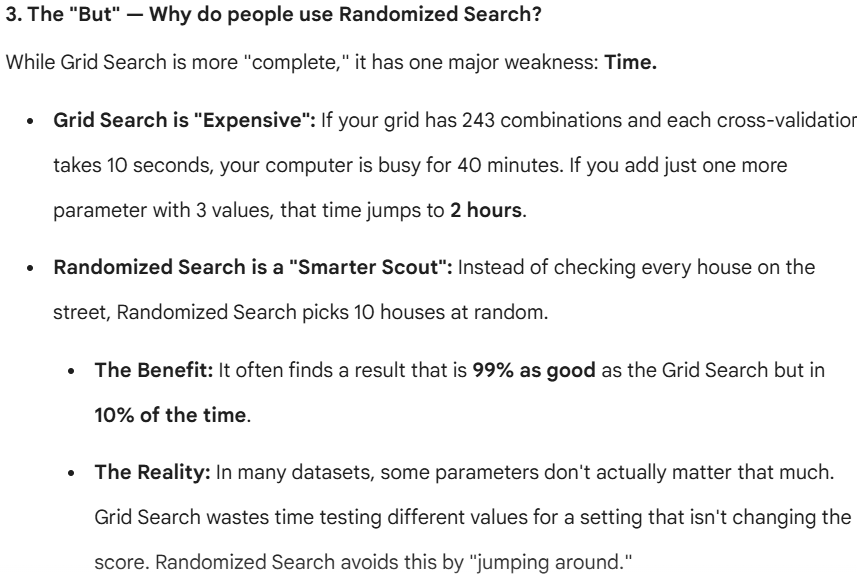
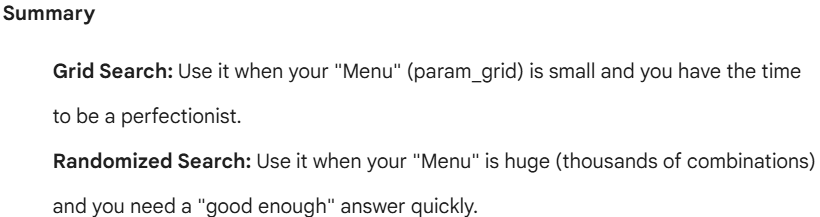

In [625]:
# Now we create a grid of hyperparameters called hyperparameter combination 

param_grid = {
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [None, 3, 6],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 1.0]
}
# we use double underscore because if we dont use double underscore, the grid cv will think that the parameters should try for both preprocess and the 
# model (previous cell). So instead of that we are using the prefix 'model' which means telling grid search cv that this parameter tuning that we are 
# doing is only for this model. That's why we use the prefix 'model' in the param grid. It's just telling the grid cv that these are not for 'preprocess'.
# grid search cv is better than randomized search cv because grid doesnt leave out any combination whereas randomized would randomly pick a combination. 
# The grid 1stly, chooses 0.03, None, 15, 20, 0.0. 2ndly, 0.03, 3, 15, 20, 0.0. 3rdly, 0.03, 6, 15, 20, 0.0. Then 0.05, None, 15, 20, 0.0. And so on. 
# grid also perform cross-valiadtion on each combination. 
# for this combination of gradient boosting, it would run 5 times because cross-validation k=5. 
# performing their permutations and combinations, we get 243 combinations. 

In [626]:
grid = GridSearchCV(
    estimator=hgb_pipe, # The Blueprint: Tell it which model and preprocessing steps to use.
    param_grid=param_grid, # The Menu: Give it the list of different settings (knobs) to try.
    cv=cv, # The Test: Use our K-Fold (5 splits) to make sure the results are stable.
    scoring="neg_root_mean_squared_error", # It's basically the ranking. It tries to do all these combinations, train the model on the data, find 
                                    # which combination gives you the lowest root mean squared error. The Goal: Tell the computer that the 'Winner' is 
                                    # whoever has the smallest error (since it's negative, the 'highest' negative value).
    n_jobs=1, # The Workload: Run tests one-by-one. Means use only 1 core of my CPU so all the training happens one after the another. If it is -1, 
              # then it uses all CPU scores. Skelearn dont use GPU score, but only CPU scores. But -1 would say use all the training in parallel. 
              # (Using -1 is like hiring 8 workers to do it at once; 1 is doing it yourself). 
    verbose=1 # The Progress Report: Tell the computer to 'talk' to us and show 
              # how many models it has finished so we don't think it's frozen.
)

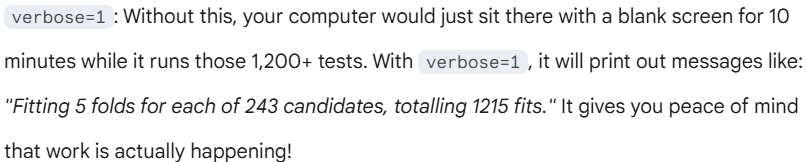

In [627]:
# perform grid search
# This command tells the GridSearchCV 'Manager' to take the training data 
# and start running every single combination from your param_grid.

grid.fit(X_train, y_train)

# What is happening "under the hood"?
# The Combinations: It starts with your first set of settings (e.g., learning_rate=0.03, max_depth=None).
# The Cross-Validation: It doesn't just train once. It splits your data 5 times, training on 4 parts and testing on 1, just like you did in the tournament.
# The Recording: It saves the average RMSE for that specific combination.
# The Loop: It moves to the next combination and repeats everything until it has finished all 243 combinations.
# The Final Step (Refit): Once it finds the "Gold Medal" combination (the one with the lowest error), it does one final training on the entire X_train 
# dataset using those best settings. This ensures your final model is as smart as possible.

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__l2_regularization': [0.0, 0.1, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [None, 3, ...], 'model__max_leaf_nodes': [15, 31, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls t

In [628]:
print("=== Tuned HistGB (CV) ===")

print("\nBest Hyperparameters:\n", grid.best_params_) # the best possible combination 

# New, improved error score
print("\nBest CV RMSE:", -grid.best_score_) # we dont want the score in negative so we added a minus sign

# Our previous best score (from the HistGB model before tuning) was about $48,070. After trying 1,215 different combinations, the "Super-Model" 
# brought that error down to $47,408. We just made our AI $662 more accurate per house!

=== Tuned HistGB (CV) ===

Best Hyperparameters:
 {'model__l2_regularization': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': None, 'model__max_leaf_nodes': 63, 'model__min_samples_leaf': 20}

Best CV RMSE: 42821.21768664254


In [629]:
grid.best_score_ 

np.float64(-42821.21768664254)

In [630]:
-grid.best_score_ # we dont want the score in negative

np.float64(42821.21768664254)

#### **Negative root mean squared error**

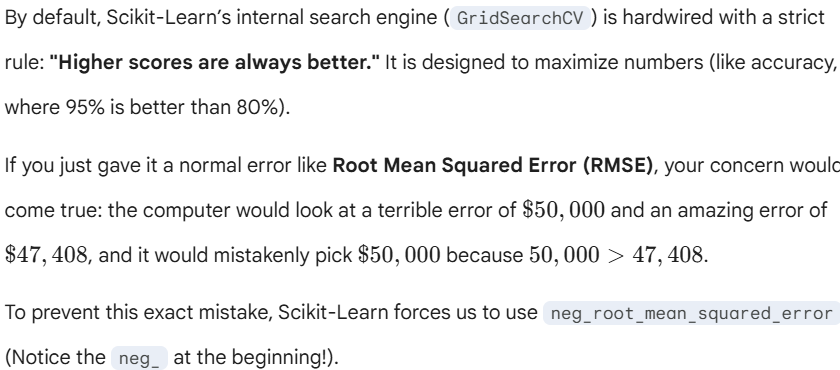

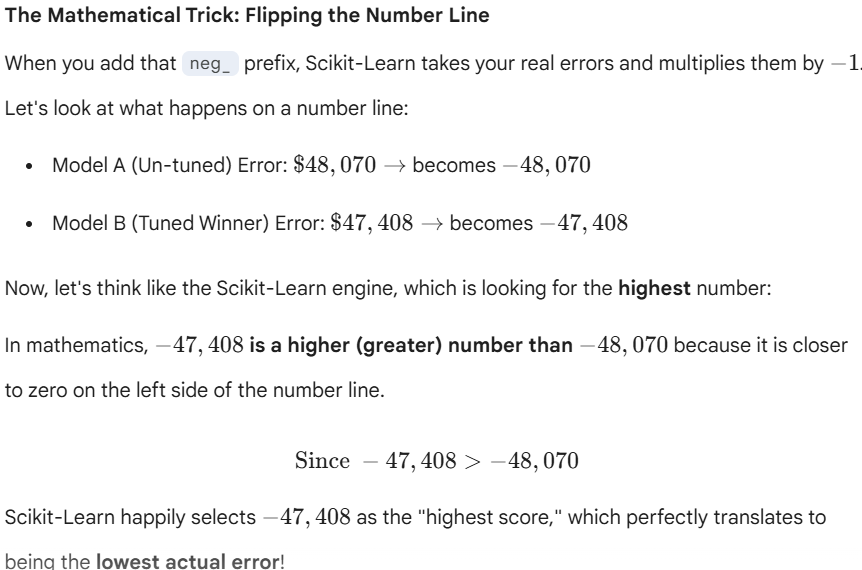

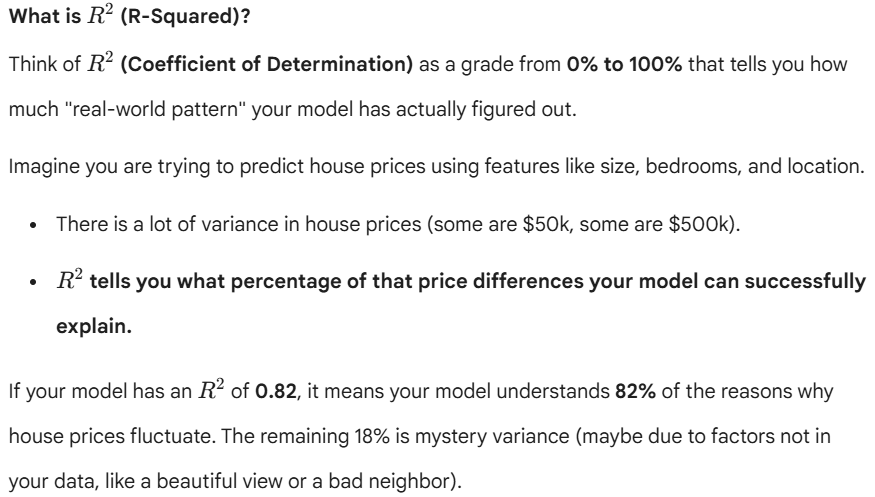
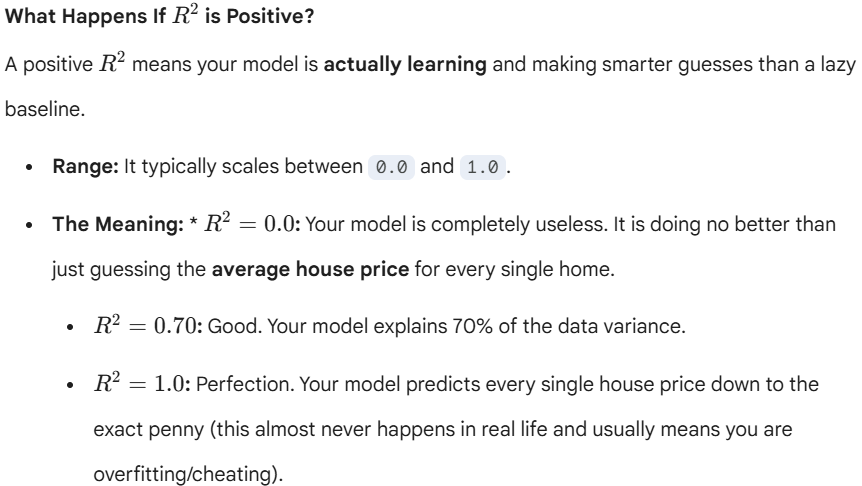
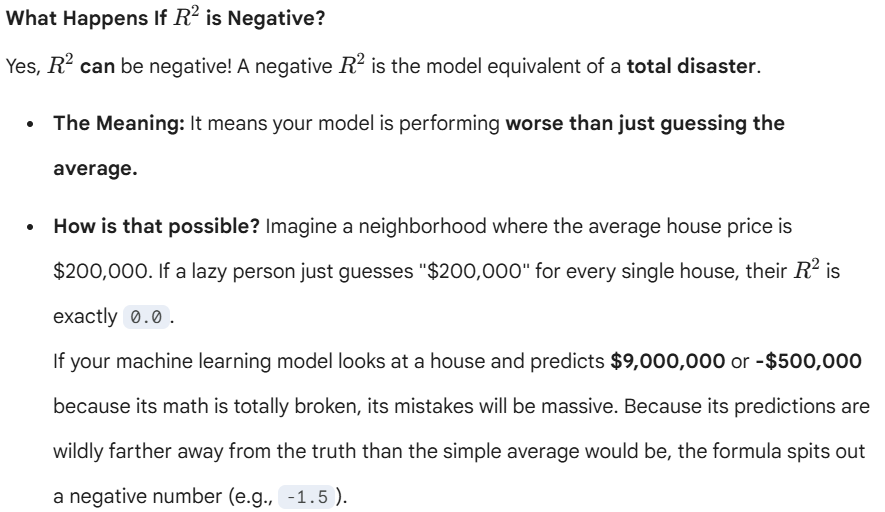
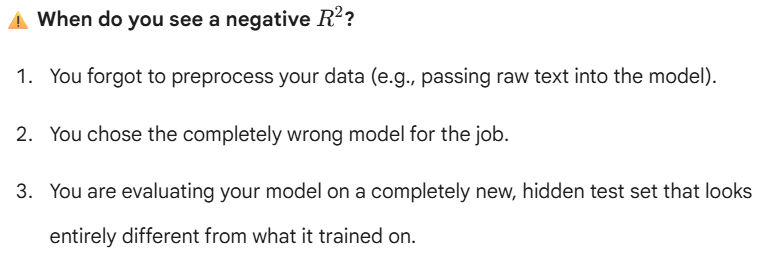

In [631]:
# classification - accuracy_score - highest - best_model

# regression - error - lowest - best_model

**8. Retraining the model with best params**

In [632]:
# Manually recreating the absolute champion model setup.
# You took the winning hyperparameter values from your 'grid.best_params_' output 
# and hardcoded them directly into a brand new, clean Pipeline.
hgb_best = Pipeline(
    steps=[
        # Keeps the exact same cleaning/scaling/encoding setup as before
        ("preprocess", preprocess), 
        
        # This is your "Super-Brain" configured with the exact mathematical numbers
        # that beat all other 242 variations in the tournament.
        ("model", HistGradientBoostingRegressor(
            l2_regularization=0.1,   # Tiny penalty to prevent overfitting
            learning_rate=0.1,       # The optimal step size for tree learning
            max_depth=None,          # Trees can grow deep as long as other rules are met
            max_leaf_nodes=63,       # Allowed to be double the complexity of standard trees
            min_samples_leaf=20      # Ensures branches don't isolate tiny groups of houses
        ))
    ]
)

In [633]:
# Checking Scikit-Learn's automatic champion storage.
# This single line is a shortcut! 'grid.best_estimator_' automatically contains 
# the EXACT same pre-trained pipeline you just typed out above. 
# Running this cell will print out an interactive diagram showing you that 
# the grid search manager is already holding your polished champion model.
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

- now u have already found the best estimator that gave u the score 47408. this comes from 1 of the combinations of 4 folds (4 training set + 1 testing set). we can use it for prediction. But we cal also use it to retarin our entire original dataset bcoz this also has only 4 folds. 

In [634]:
# train best model on entire training data (can also be done with refit=True in grid search)
# Up until now, your models were being trained on fractional pieces of the data 
# during the 5-fold cross-validation tournament to see who was smartest.
# Now that the 'HistGradientBoostingRegressor' with those exact settings 
# (max_leaf_nodes=63, l2_regularization=0.1) has won, we want it to absorb 
# every single drop of knowledge from the entire 'X_train' and 'y_train' datasets.

hgb_best.fit(X_train, y_train)

# Under the hood, this single command executes two critical stages sequentially:
# 1. ("preprocess"): It learns the median values for missing data and calculates 
#    the scaling factors from your numerical training columns, while mapping out 
#    all the unique categories for your categorical columns.
# 2. ("model"): It builds the final collection of gradient-boosted trees using 
#    the entire dataset, optimizing its final weights.
#
# Your champion pipeline is now officially "armed" and fully prepared to handle 
# the unseen test data!

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

**9> Final Evaluation**

In [635]:
train_final_pred = hgb_best.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("\n Final Model (Tuned HGB) Train Performance: ")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"MAE: {train_final_mae:.3f}")
print(f"R2: {train_final_r2:.3f}")


 Final Model (Tuned HGB) Train Performance: 
RMSE: 32779.370
MAE: 22706.552
R2: 0.886


**Comparison of the Baseline metric results & Final model train performance:**

Train Baseline Metrics (Linear Regression): 
- RMSE: 68433.937
- MAE: 49594.842
- R2: 0.650

Final Model (Tuned HGB) Train Performance: 
- RMSE: 36189.907
- MAE: 24605.445
- R2: 0.902

1. **The RMSE Battle (Average Error Size)**
Baseline (Linear Regression): $68,433.937
Final Model (Tuned HGB): $36,189.907
The Winner: Tuned HGB (An improvement of $32,244 per house!)
*Why this matters:* RMSE penalizes large mistakes heavily. A baseline RMSE of over $68k means the simple linear model was making some massive, wild guessing errors. Your tuned HistGradientBoosting model cut that error nearly in half, meaning its predictions are much tighter and vastly more reliable.

2. **The MAE Battle (Typical Absolute Error)**
Baseline (Linear Regression): $49,594.842
Final Model (Tuned HGB): $24,605.445
The Winner: Tuned HGB (An improvement of $24,989)
*Why this matters:* In machine learning, the word "miss" is just a casual, plain-English term for prediction error. It tells you exactly how far off the target your model's guess was from the actual value.
When looking at the MAE (Mean Absolute Error) battle, think of your model as playing a game of darts. The bullseye is the actual sale price of the house, and the model’s prediction is where the dart lands. The "miss" is the physical distance between the dart and the bullseye.

*How the "Miss" is Calculated*
If a house actually sells for $200,000, but your model predicts it will sell for $225,000, your model "missed" the true value by $25,000.
MAE calculates this exact distance for every single house in your dataset, strips away any negative signs (because a miss is a miss, whether you guessed too high or too low), and takes the average of all those misses.
- Baseline (Linear Regression) MAE: $49,594.842
What this means: On average, when the Linear Regression model takes a guess at a house price, its typical "miss" is roughly $50,000. If you rely on this model to price a home, you should expect it to routinely over- or under-price it by a massive margin.

- Final Model (Tuned HGB) MAE: $24,605.445
What this means: On average, your tuned HistGradientBoosting model only "misses" the true house price by about $24,600.

3. **The $R^2$ Score Battle (Variance Explained)Baseline (Linear Regression):** $0.650$ ($65.0\%$)Final Model (Tuned HGB): $0.902$ ($90.2\%$)The Winner: Tuned HGB
*Why this matters:* Linear Regression only understood 65% of the underlying patterns dictating house prices in your dataset, leaving 35% completely up to mystery or bad assumptions. Your Tuned HGB captures a massive 90.2% of the variance. It has a fundamentally deeper grasp of how features like geography, income, and house age interact to determine price.

In [636]:
test_final_pred = hgb_best.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("\n Final Model (Tuned HGB) Test Performance: ")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"MAE: {test_final_mae:.3f}")
print(f"R2: {test_final_r2:.3f}")


 Final Model (Tuned HGB) Test Performance: 
RMSE: 43597.931
MAE: 29499.858
R2: 0.809


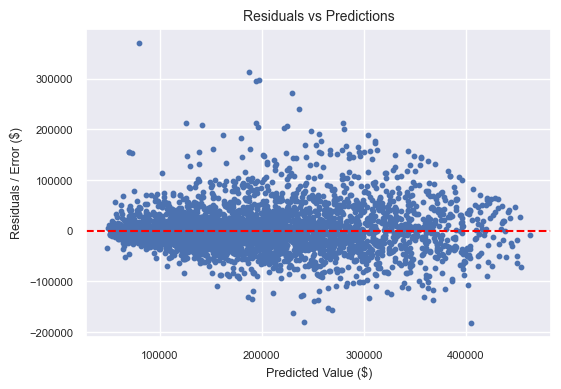

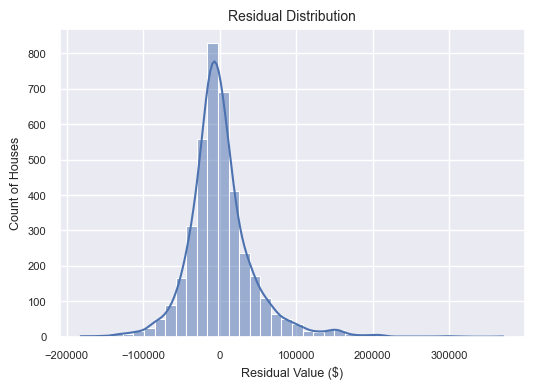

In [637]:
# Residual plot

# 1. Calculate the raw errors (Residuals) for the test set.
# A "residual" is simply the actual house price minus the predicted house price.
# Positive residual = The model under-predicted (the house was more expensive than guessed).
# Negative residual = The model over-predicted (the house was cheaper than guessed).
residuals = y_test - test_final_pred

# ==========================================
# PLOT 1: Residuals vs. Predictions Scatter Plot
# ==========================================
plt.figure(figsize=(6, 4))

# This creates a scatter plot where the X-axis is your model's guess, 
# and the Y-axis is how far off that guess was.
plt.scatter(test_final_pred, residuals, s=10)

# Draws a perfectly horizontal reference line at 0.
# A dart that lands exactly on this line represents a perfect prediction (0 error).
plt.axhline(0, color='red', linestyle='--') # added color/linestyle comment for clarity

plt.title("Residuals vs Predictions")
plt.xlabel("Predicted Value ($)")
plt.ylabel("Residuals / Error ($)")
plt.show()

# What to look for in Plot 1:
# - Ideal Scenario: A random, evenly distributed "cloud" of dots centered around 0.
# - Warning Sign: If the cloud shapes like a funnel (gets wider for expensive houses),
#   it means your model struggles and gets wildly volatile when predicting luxury homes.


# ==========================================
# PLOT 2: Residual Distribution Histogram
# ==========================================
plt.figure(figsize=(6, 4))

# This counts how often different sizes of errors occur and plots them as bars.
# 'kde=True' draws a smooth density curve over the bars to show the overall shape.
sns.histplot(residuals, bins=40, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Residual Value ($)")
plt.ylabel("Count of Houses")
plt.show()

# What to look for in Plot 2:
# - Ideal Scenario: A perfect bell curve (Normal Distribution) centered exactly at 0.
#   This proves your model's errors are purely random noise.
# - Warning Sign: If the tail is pulled far to the right or left (skewed), your model 
#   has a systematic bias (e.g., systematically underestimating certain types of properties).

**The first plot**
1. **The Core Anatomy of the Plot**
- The Horizontal Red Dashed Line ($y = 0$): This is the "Perfect Prediction Line." If a dot lands exactly on this line, it means your model predicted the house price perfectly down to the penny (Error = $0).
- Dots Above the Red Line ($> 0$): These are Under-predictions. The actual house price was higher than what your model guessed. (For example, a residual of $+\$100,000$ means a house sold for $300k, but your model only guessed $200k).
- Dots Below the Red Line ($< 0$): These are Over-predictions. Your model guessed a price that was too high compared to what the house actually sold for.

2. **What Your Plot Reveals (The Good News)**
An ideal residual plot looks like a completely random, uniform "cloud" of points evenly distributed around the zero line, resembling a horizontal band.

Your model achieves this beautifully for the vast majority of houses priced between $50,000 and $350,000. The thickest cluster of dots forms a tight, balanced cloud around zero. This tells us that for typical, average-priced homes, your model's errors are small, symmetric, and purely random noise—which is exactly what we want!

3. **The Warning Signs (The Hidden Patterns)** If you look closely at the edges, your plot reveals two distinct mathematical phenomena that you should absolutely highlight in your project analysis:
- The Distinct Diagonal Boundary Line (Top-Right)Do you see that sharp, perfectly straight diagonal line of dots cutting down on the upper-right side?**Why it's happening:** This is a classic indicator of a **capped maximum value** in your dataset. In many real estate datasets (like the famous California Housing dataset), the target house prices are artificially capped at a hard maximum limit (e.g., $500,001).Since $Residual = Actual - Predicted$, if the $Actual$ value is capped at a fixed maximum constant, the equation becomes a straight linear function of the prediction ($Residual = CappedValue - Predicted$). This creates that mathematical "ceiling" line. It proves your model is trying to predict higher values, but the dataset limits how high the actual recorded values can go.

In data science, when we say a variable is **capped** (also known as **top-coded** or **censored**), it means that any value above a certain pre-determined threshold has been artificially rounded down to a fixed maximum limit.
In the context of your housing dataset, the **Target Variable** (median_house_value) is what is capped.

1. *The Real-World Cause*
When data collection agencies (like the US Census Bureau) gather housing data, they often cap luxury home prices to protect privacy or because their recording systems have a maximum limit.
For example, in the famous California Housing dataset, any neighborhood with a median house value of $500,000 or more was automatically recorded as exactly $500,001, regardless of whether the actual homes were worth $600,000, $1 million, or $5 million.
2. *The Mathematical Trap for Your Model*
Your tuned HistGradientBoosting model doesn't know the data was tampered with. It looks at the features (like a massive 10-room mansion in a wealthy coastal area with a high median income) and correctly calculates: "Hey, this house should be worth $650,000!"
But when scikit-learn checks the answer key (y_test), the dataset says the value is exactly $500,001.
3. *How This Creates the Diagonal Line* Let's look at the math behind your residuals for those luxury homes. The formula for a residual is:$$\text{Residual} = \text{Actual Price} - \text{Predicted Price}$$Because the actual price is capped at a constant maximum number ($\$500,001$), for every single luxury home your model evaluates, the formula turns into:$$\text{Residual} = 500,001 - \text{Predicted Price}$$This is the exact mathematical equation for a downward-sloping straight line ($y = C - x$).If your model predicts $450,000, the residual is $500,001 - 450,000 = \mathbf{+50,001}$ (Above the red line).If your model predicts $500,000, the residual is $500,001 - 500,000 = \mathbf{+1}$ (Right on the red line).If your model predicts $540,000, the residual is $500,001 - 540,000 = \mathbf{-39,999}$ (Below the red line).If you look back at your scatter plot, that sharp diagonal line cuts right through those exact coordinates on the right side! It is a beautiful visual proof that your model is actually smart enough to predict high values, but the dataset is artificially pulling the true values down.

**The second plot**

1. **The Good News:** It is Perfectly Centered on Zero.
The absolute highest peak of your histogram sits exactly at 0.
*What this means:* The most common error your model makes is an error of $0 (or very close to it).
*The structural takeaway:* This proves that your model is **unbiased**. It isn't systematically overpredicting or underpredicting across the entire dataset. On average, its guesses balance out perfectly.

In data science and statistics, saying a model is **unbiased** means that, on average, its predictions are perfectly on target. It doesn't have a systematic tendency to guess too high or too low.
Think of it as the ultimate sign of fairness in your model's math.

Your residual histogram proves your model is unbiased because **the peak is perfectly balanced at 0**.
If your model were biased, the entire mountain shape would be shifted away from zero:

- If the peak had shifted to the **left (negative numbers)**, it would mean your model is systematically overpredicting (guessing prices that are too high).
- If the peak had shifted to the **right (positive numbers)**, it would mean your model is systematically underpredicting (guessing prices that are too low).
Because your peak sits right on **0**, your model’s overpredictions and underpredictions cancel each other out mathematically. It means your model isn't "rigged" or leaning heavily in one wrong direction!

2. **The Shape: High Kurtosis (The "Leptokurtic" Peak)** Notice how the center of your graph isn't a completely smooth, gentle dome. Instead, it is very tall, sharp, and narrow right around zero, with relatively thin "tails" spreading out to the left and right.
In statistics, this shape is called leptokurtic (or a distribution with high kurtosis).What this means for your model: This is a fantastic sign! It means that a massive, overwhelming majority of your test set predictions have errors that are clustered tightly between $-\$25,000$ and $+\$25,000$. The model is highly precise for the bulk of your data points.

3. **The Warning Sign:** The Long Right Tail (Positive Skewness)If you look closely at the base of the mountain, the left side cuts off fairly quickly around $-\$150,000$. However, the right side has a long, low tail that stretches all the way out past $+\$200,000$ and $+\$300,000$.This asymmetry is known as **positive skewness** (skewed to the right).
*Why it's happening:* Remember that formula: $\text{Residual} = \text{Actual} - \text{Predicted}$. To get a massive positive residual like $+\$300,000$, the **Actual Price** must be much, much higher than what your model predicted.
*The real-world culprit:* These represent luxury properties or sudden real-estate anomalies where a house sold for an astronomical amount, but your model predicted a normal, moderate price. This ties right back into the heteroscedasticity we spotted on your scatter plot—your model occasionally gets caught off guard by ultra-expensive outlier homes, causing these large positive errors.

In [638]:
# This is a helper function designed to take a single home's real estate characteristics and predict its market value using your trained pipeline model.
# It acts as a clean interface or "bridge" for an application (like a web app or an API backend). Instead of forcing a user to deal with 
# complex pandas DataFrames, they can just pass standard Python numbers and strings into this function, and it returns a clean, individual price estimate.

def predict_house_price(
    model,                          # The trained pipeline object (e.g., your 'hgb_best')
    longitude: float,               # Geographic coordinate: East/West positioning
    latitude: float,                # Geographic coordinate: North/South positioning
    housing_median_age: float,      # Median age of the houses in that block
    total_rooms: float,             # Total number of rooms within the block
    total_bedrooms: float,          # Total number of bedrooms (can pass np.nan if missing)
    population: float,              # Total number of people residing in the block
    households: float,              # Total number of separate households/families
    median_income: float,           # Median income for households (highly important feature!)
    ocean_proximity: str            # Categorical string (e.g., 'NEAR BAY', '<1H OCEAN', 'INLAND')
) -> float:                         # '-> float' is a type hint indicating this function returns a decimal number
    """
    Predict median_house_value for one new house, 
    total bedrooms can be np.nan (pipeline will impute).
    """
    
    # 1. Convert the individual raw arguments into a 1-row Pandas DataFrame.
    # Scikit-learn models and pipelines are strict: they cannot accept loose individual variables.
    # They expect data organized in a tabular format (rows and columns) matching the exact schema
    # the model was originally trained on. Wrapping the dictionary inside brackets [{...}] 
    # creates a single row with the proper feature column headers.
    new_row = pd.DataFrame([{
        "longitude": longitude,
        "latitude": latitude,
        "housing_median_age": housing_median_age,
        "total_rooms": total_rooms,
        "total_bedrooms": total_bedrooms,
        "population": population,
        "households": households,
        "median_income": median_income,
        "ocean_proximity": ocean_proximity
    }])

    # 2. Feed the new row to the pipeline, get the prediction, and extract the single value.
    # - 'model.predict(new_row)' passes the dataframe through the pipeline. 
    #   The pipeline will impute missing values (if total_bedrooms is nan), scale numbers, 
    #   one-hot encode the 'ocean_proximity' string, and calculate the price.
    # - Scikit-learn outputs predictions as a NumPy array (e.g., array([235400.12])).
    #   We use '[0]' to grab the very first element out of that array.
    # - 'float(...)' casts it from a NumPy float data type to a native Python float.
    return float(model.predict(new_row)[0])

In [639]:
# ==========================================
# TESTING THE PREDICTION INTERFACE (DEPLOYMENT READY)
# ==========================================

# 1. Execute the function using a mock property scenario.
# We call our custom 'predict_house_price' wrapper function and feed it 
# raw, single values representing a real house profile.
# Notice that we pass 'hgb_best' (our fully trained, tuned champion pipeline) 
# as the 'model' argument so it handles the heavy lifting under the hood.
example_pred = predict_house_price(
    model = hgb_best,
    longitude=-122.230,        # Exact geographical longitude coordinate
    latitude=37.880,         # Exact geographical latitude coordinate
    housing_median_age=41,   # The property block age (mature neighborhood)
    total_rooms=880,         # Combined room count for the block group
    total_bedrooms=129,      # Combined bedroom count for the block group
    population=322,          # Local neighborhood population count
    households=126,          # Number of families living in this block group
    median_income=8.3252,    # High income tier factor (strongly weights the valuation upward)
    ocean_proximity="NEAR BAY" # Categorical location description passed as a plain string
)

# 2. Display the final calculated output value to the screen.
# - 'round(example_pred, 2)' rounds the resulting raw decimal prediction to two cents.
# - '\n' injects a clean line break before the string to make the terminal printout neat.
print("\nExample prediction:", round(example_pred, 2))


Example prediction: 391032.38


📈 Ways to improve performance
- Create ratio features
    - rooms_per_household
    - bedrooms_per_room
    - population_per_household
- Try log transformation on the target variable.
- Tune max_iter and max_bins for HistGradientBoosting.
- Try advanced boosting models like XGBoost or LightGBM.
- Do error analysis by location or price ranges instead of only metrics.
- Use spatial or grouped validation for location-based data.

**Custom Feature Engineering Transformer**

In [640]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

# Define a custom class that inherits from BaseEstimator and TransformerMixin.
# This allows our custom feature engineering to integrate seamlessly into a scikit-learn Pipeline.
class AdvancedHousingFeatures(BaseEstimator, TransformerMixin):
    def __init__(self): # __init__ is the constructor. used to initialize an object's attributes when created.
        # Since this transformer always does the exact same math and doesn't need configurations 
        # or settings, it has nothing to do. We use 'pass' as an empty placeholder statement 
        # so Python doesn't throw a syntax indentation error.
        # Coordinates for major economic/high-value hubs in California
        self.san_francisco = (37.7749, -122.4194)
        self.los_angeles = (34.0522, -118.2437)

    def fit(self, X, y=None):
        # 'y=None' is an unused target parameter included to play by scikit-learn's structural rules. 
        # Pipelines expect every component's .fit() method to accept a 'y' variable downstream.
        # 'return self' returns the trained instance of the transformer itself. This allows 
        # methods to be chained together cleanly (e.g., transformer.fit(X).transform(X)). 
        # Since our ratio adder doesn't actually learn parameters from the data, it returns immediately.
        return self # The fit step does not need to learn any parameters from the data, so it returns itself.
    
    def transform(self, X):
        X_copy = X.copy() 
        # Explicitly make a deep copy of the incoming DataFrame to prevent modifying original data in place.

        X_copy["rooms_per_household"] = X_copy["total_rooms"] / X_copy["households"] 
        # Calculate 'rooms_per_household' by dividing total rooms by the total households column.

        X_copy["bedrooms_per_room"] = X_copy["total_bedrooms"] / X_copy["total_rooms"] 
        # Calculate 'bedrooms_per_room' by dividing total bedrooms by the total rooms column.

        X_copy["population_per_household"] = X_copy["population"] / X_copy["households"]
        # Calculate 'population_per_household' by dividing total block population by total households.

        # 2. Advanced Spatial Engineering (Distance to Hubs)
        # Using Euclidean approximation for coordinate distances
        X_copy["dist_to_sf"] = np.sqrt(
            (X_copy["latitude"] - self.san_francisco[0])**2 + 
            (X_copy["longitude"] - self.san_francisco[1])**2
        )
        X_copy["dist_to_la"] = np.sqrt(
            (X_copy["latitude"] - self.los_angeles[0])**2 + 
            (X_copy["longitude"] - self.los_angeles[1])**2
        )
        
        # Combine them to get distance to the closest major city
        X_copy["dist_to_nearest_hub"] = X_copy[["dist_to_sf", "dist_to_la"]].min(axis=1)

        return X_copy
        # Return the modified DataFrame containing both the original features and the 3 new engineered columns.
        # This pushes the upgraded dataset into the next stage of the pipeline while leaving 
        # your original raw DataFrame completely untouched and clean in memory.

**Updated Preprocessing & Modeling Pipeline**

In [641]:
# 1. COMPARTMENTALIZED IMPORTATION PHASE

# Scikit-learn is highly modular to save memory and optimize processing speed. 
# Instead of loading the entire massive library at once, we open specific closed sub-directories (modules) to pull out only the individual tools we need.

from sklearn.pipeline import Pipeline
# Pipeline: A linear conveyor belt container that chains sequential transformations together.

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
# ColumnTransformer: A parallel routing switchboard used to apply different operations to different columns.
# TransformedTargetRegressor: A specialized meta-wrapper that handles mathematical scaling of the target variable (y).

from sklearn.preprocessing import StandardScaler, OneHotEncoder
# StandardScaler: Forces numerical columns to center around a mean of 0 and variance of 1.
# OneHotEncoder: Converts categorical text strings into a sparse binary matrix of 0s and 1s.

from sklearn.impute import SimpleImputer
# SimpleImputer: A data-patching tool designed explicitly to find blank cells (NaN) and replace them.

from sklearn.ensemble import HistGradientBoostingRegressor
# HistGradientBoostingRegressor: An advanced ensemble machine learning model built on consecutive decision trees.

from lightgbm import LGBMRegressor 
# LightGBM is an advanced gradient boosting framework developed by Microsoft.
# It converts numerical features into discrete histograms to run incredibly fast, 
# consume very little RAM, and scale efficiently on large tabular datasets
# LGBMRegressor is LightGBM's specialized class for predicting continuous numbers.
# It builds consecutive decision trees level-by-level based on the biggest error drops.
# It integrates perfectly with standard Scikit-Learn Pipelines and wrappers.

import numpy as np

# 2. FEATURE EXTRACTION & IDENTIFICATION

# Extract numerical columns from features, explicitly excluding the categorical location column.
# A list comprehension checks every column header in your training set to isolate numeric variables.
numerical_features = [col for col in X_train.columns if col != "ocean_proximity"]

# Isolate the categorical feature column into its own specific processing array.
# Storing this header string lets ColumnTransformer know exactly where to apply string transformations.
categorical_features = ["ocean_proximity"]

# Tell the pipeline about the 4 new columns our custom transformer creates
extended_numerical_features = numerical_features + [
    "rooms_per_household", 
    "bedrooms_per_room", 
    "population_per_household",
    "dist_to_nearest_hub"
]

# 3. SEGMENTED DATA SUB-PIPELINES

# Scikit-learn requires tuples structured as ("User_Defined_Name", Object_Instance()) for pipeline steps. 
# The name is a nickname you invent so you can call on this step later.

# Build a dedicated sub-pipeline for preprocessing numerical features sequentially.
numerical_transformer = Pipeline(
    steps=[
        # "imputer" is the custom key name; SimpleImputer is the object doing the labor. 
        # strategy="median" tells it to use the column's middle value. Its sole job is 
        # handling missing values, looking automatically for np.nan background targets.
        ("imputer", SimpleImputer(strategy="median")), 
        
        # "scaler" is the key name; StandardScaler is the object value.
        # This standardizes column dimensions so large values do not overwhelm the tree weights.
        ("scalar", StandardScaler()) 
    ]
)

# Build a dedicated sub-pipeline for preprocessing categorical features.
categorical_transformer = Pipeline(
    steps=[
        # Safe fallback to handle any missing string data using the most common category.
        ("imputer", SimpleImputer(strategy="most_frequent")), 
        
        # Convert localized location text strings into binary one-hot column configurations.
        ("onehot", OneHotEncoder(handle_unknown="ignore")) 
    ]
)

# 4. COMPOSITE STRUCTURAL PREPROCESSING

# Combine the sub-pipelines using ColumnTransformer to map operations to their respective columns.
# We must use triplets here: ("Name", Transformer_Pipeline, Target_Columns). 
# If we omit the third element, the router has no way of knowing WHERE to apply the transformation.
preprocess_core = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, extended_numerical_features),     # Route raw numerical columns through the numeric pipeline.
        ("cat", categorical_transformer, categorical_features)  # Route categorical columns through the categorical pipeline.
    ]
)

# Construct a master processing pipeline that chains our custom engineering step with structural transformations.
# This serves as the overarching assembly line for your features (X).
feature_and_preprocess_pipeline = Pipeline(
    steps=[
        # Phase 1: Inject engineered ratio columns into the DataFrame using our custom class.
        ("advanced_features", AdvancedHousingFeatures()), 
        
        # Phase 2: Handle parallel imputation, scaling, and encoding across the columns.
        # Notice that we must recreate column mapping dynamically if column positions shift,
        # but because our ratio columns are added onto the end, ColumnTransformer maps cleanly to the baseline ones.
        ("preprocess", preprocess_core) 
    ]
)

# 5. Initialize the LightGBM Regressor inside our Target Log Wrapper
lgbm_engine = LGBMRegressor(random_state=RANDOM_STATE, n_estimators=200, learning_rate=0.05)

optimized_target_wrapper = TransformedTargetRegressor(
    regressor=lgbm_engine,
    func=np.log1p,       # Automatically log-transforms target prices to handle skewness
    inverse_func=np.expm1 # Automatically converts predictions back to normal dollar values
)

# 6. Final Master Production Pipeline
production_pipeline = Pipeline(steps=[
    ("feature_prep", feature_and_preprocess_pipeline),
    ("model_container", optimized_target_wrapper)
])

# Train the entire upgraded framework on your cleaned dataset
production_pipeline.fit(X_train, y_train)
print("Upgraded Production Pipeline Trained Successfully with LightGBM!")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001136 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2866
[LightGBM] [Info] Number of data points in the train set: 15740, number of used features: 16
[LightGBM] [Info] Start training from score 12.033426
Upgraded Production Pipeline Trained Successfully with LightGBM!


**Expanded Advanced Hyperparameter Tuning**

In [642]:
# 1. VALIDATION STRATEGY SPECIFICATION

# We import scikit-learn's hyperparameter search and data splitting utilities.
from sklearn.model_selection import GridSearchCV, KFold

# Set the number of cross-validation splits (folds) to 5.
k = 5

# Instantiate a K-Fold cross-validation split engine strategy.
# - n_splits=k: Divides the dataset into 5 equal, consecutive chunks (folds).
# - shuffle=True: Shuffles the rows randomly before chopping them into folds, 
#   ensuring an even, non-biased distribution of target properties.
# - random_state=RANDOM_STATE: Locks the random shuffling seed so that your splits
#   are identically repeatable every single time you execute this cell.
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)


# 2. HYPERPARAMETER CANDIDATE MENU DEFINITION

# We establish a raw python dictionary holding the tuning candidate arrays.
# Notice the single underscore prefix "regressor__": This is an intermediate structural 
# key name mapping directly inside the TransformedTargetRegressor container wrapper object.
param_grid_expanded = {
    # Options for step size scaling. Smaller values (0.05) require more trees but learn 
    # highly precise patterns; larger values (0.1) learn faster but can overshoot.
    "regressor__learning_rate": [0.05, 0.1],          
    
    # Options for the maximum number of consecutive tree boosting iterations (rounds). 
    # More trees (200) increase accuracy but risks overfitting and longer computational times.
    "regressor__max_iter": [100, 200],                 
    
    # Options limiting structural node splits. 63 allows complex, detailed interactions,
    # while 31 keeps the trees shallower, acts as regularization, and prevents overfitting.
    "regressor__max_leaf_nodes": [31, 63],             
    
    # Options for splitting numerical feature boundaries into distinct quantized bins.
    # Higher bins (255) provide finer feature resolution; lower bins (127) speed up processing.
    "regressor__max_bins": [127, 255],                 
    
    # The minimum number of training instances mandatory to remain inside a terminal leaf.
    # Higher values (50) act as a regularizer, preventing trees from memorizing outlier points.
    "regressor__min_samples_leaf": [20, 50]            
}


# 3. END-TO-END PIPELINE ASSEMBLY

# We bind our preprocessing data steps together with the model estimator into one unified pipeline object.
# This macro architecture prevents any data leakage between validation sets during the training loops.
full_execution_pipeline = Pipeline(
    steps=[
        # Step 1 (Nickname: "feature_prep"): Applies custom ratio feature calculations, 
        # missing data median imputations, and feature data scaling/one-hot transformations.
        ("feature_prep", feature_and_preprocess_pipeline), 
        
        # Step 2 (Nickname: "model_container"): Houses the log target wrapper containing 
        # our core HistGradientBoosting algorithm engine.
        ("model_container", optimized_hgb_model)           
    ]
)


# 4. NESTED ALGORITHMIC ADDRESS RESOLUTION

# Because our target model is nested inside an assembly line Step named "model_container", 
# scikit-learn requires a multi-layered path address to locate the parameters:
# Path required: model_container__regressor__<hyperparameter_name>
#
# This single dictionary comprehension loops over our candidate options list and automatically
# appends the "model_container__" routing string key prefix directly onto the front of every parameter path.
param_grid_nested = {f"model_container__{key}": val for key, val in param_grid_expanded.items()}


# 5. CROSS-VALIDATED GRID SEARCH ENGINE CONFIGURATION

# Instantiate the complete combination cracker object. It evaluates every option permutation.
grid_search_optimized = GridSearchCV(
    # Provide the master execution pipeline containing both data engineering and the model.
    estimator=full_execution_pipeline, 
    
    # Provide the nested-address dictionary containing our 32 structural combinations of parameter candidates.
    param_grid=param_grid_nested,      
    
    # Apply our 5-fold cross validation splitting instructions.
    cv=cv,                             
    
    # Use Root Mean Squared Error to evaluate accuracy. In scikit-learn, error is returned as a 
    # negative value ("neg_root_mean_squared_error") to strictly adhere to the internal "higher is better" rule.
    scoring="neg_root_mean_squared_error", 
    
    # Instruct your system to harness every single available core inside your CPU hardware chip 
    # to process parameter evaluation threads concurrently in parallel, slashing total execution wait times.
    n_jobs=-1,                         
    
    # Sets status tracking text logging. 1 ensures it prints clear text milestone progress markers to the terminal screen.
    verbose=1                          
)


# 6. BRUTE-FORCE COMPLEX COMPUTATIONAL TRAINING EXECUTION

# The execution trigger. This single line fires off the physical algorithmic loop computations.
# It multiplies your parameter possibilities by your cross-validation folds (32 options * 5 folds = 160 cycles).
# The machine runs 160 separate training/evaluation loops, identifies the mathematically superior winning settings,
# and automatically executes a final total re-fit of that winner across the entirety of your 'X_train' and 'y_train' arrays.
grid_search_optimized.fit(X_train, y_train)


# 7. OPTIMIZATION DISCOVERY REVELATION PRINTING

print("\n=== OPTIMIZED TUNED HGB (WITH LOG TARGET & RATIO FEATURES) ===")

# '.best_score_' returns scikit-learn's winning score, which is stored as a negative number. 
# We intentionally prepend a negative sign '-' to flip it back into a standard, positive real-world dollar error value.
print("Best CV RMSE Value:", -grid_search_optimized.best_score_)

# '.best_params_' returns a textual Python dictionary mapping keys to their ideal values.
# Because this outputs structural parameter strings and values instead of a score number, 
# it remains normal without any mathematical sign inversion transformations.
print("Best Chosen Parameters:", grid_search_optimized.best_params_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits

=== OPTIMIZED TUNED HGB (WITH LOG TARGET & RATIO FEATURES) ===
Best CV RMSE Value: 42003.022324591395
Best Chosen Parameters: {'model_container__regressor__learning_rate': 0.1, 'model_container__regressor__max_bins': 255, 'model_container__regressor__max_iter': 200, 'model_container__regressor__max_leaf_nodes': 63, 'model_container__regressor__min_samples_leaf': 20}


**Evaluating Advanced Competitor Models (LightGBM & XGBoost)**

In [643]:
%pip install xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [644]:
# To execute this block, ensure libraries are installed: %pip install xgboost lightgbm
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_validate
import numpy as np

# Construct a dictionary to store alternate state-of-the-art tree models.
advanced_models = {
    # Instantiate eXtreme Gradient Boosting with fixed seed guidelines.
    "XGBoost": XGBRegressor(random_state=RANDOM_STATE, n_estimators=200, learning_rate=0.05, max_depth=6),
    # Instantiate Light Gradient Boosting Machine with equivalent baseline properties.
    "LightGBM": LGBMRegressor(random_state=RANDOM_STATE, n_estimators=200, learning_rate=0.05, max_depth=6)
}

# Initialize a results list container array to hold processing score dict logs.
advanced_rows = []

# Loop through each model name and instance inside the collection dictionary.
for name, model_instance in advanced_models.items():
    
    # Wrap model instances in an automated log-target structural transformation wrapper.
    wrapped_model = TransformedTargetRegressor(
        regressor=model_instance,
        func=np.log1p,
        inverse_func=np.expm1
    )
    
    # Create an independent pipeline linking our feature engineering with the competitor model wrapper.
    comp_pipeline = Pipeline(
        steps=[
            ("feature_prep", feature_and_preprocess_pipeline),
            ("model", wrapped_model)
        ]
    )
    
    # Execute structural cross validation performance logging scores.
    scores = cross_validate(
        comp_pipeline, 
        X_train, 
        y_train, 
        cv=cv, 
        scoring={"rmse": "neg_root_mean_squared_error"}, 
        n_jobs=-1
    )
    
    # Append calculated score summaries back to the rows logging storage system.
    advanced_rows.append({
        "Model Engine": name,
        "CV Mean RMSE": -scores["test_rmse"].mean() # Inverse negative metric to extract true positive RMSE values.
    })

# Convert summary data matrices into a visual Pandas tracking summary table.
comp_df = pd.DataFrame(advanced_rows).sort_values("CV Mean RMSE")
print("=== Advanced Boosting Model Results ===")
print(comp_df)

=== Advanced Boosting Model Results ===
  Model Engine  CV Mean RMSE
0      XGBoost     43500.515
1     LightGBM     43535.055


**Deep Stratified Error Analysis (By Location & Price Tier)**

In [645]:
# Extract predictions from our optimized pipeline engine on the unseen validation test split array.
final_optimized_predictions = grid_search_optimized.predict(X_test)

# Build a dedicated data review visualization frame isolating targets, predictions, and locations.
analysis_df = pd.DataFrame({
    "ActualPrice": y_test, # Unseen actual baseline home dollar evaluation column.
    "PredictedPrice": final_optimized_predictions, # Associated prediction generated array numbers.
    "OceanProximity": X_test["ocean_proximity"] # Extracted geo categorical indexing string context.
})

# FIXED TYPO HERE: Changed "AbdoluteError" to "AbsoluteError"
analysis_df["AbsoluteError"] = (analysis_df["ActualPrice"] - analysis_df["PredictedPrice"]).abs()

# Segment house values into three descriptive price tiers using boundary categorization.
analysis_df["PriceTier"] = pd.cut(
    analysis_df["ActualPrice"],
    bins=[0, 150000, 350000, np.inf], # Price intervals tracking: Low, Moderate, Luxury estates.
    labels=["low(<150k)", "Medium(150k-350k)", "High(>350k)"]
)

# Aggregate and extract the average error size grouped across spatial geographic coordinates categories.
error_by_location = analysis_df.groupby("OceanProximity")["AbsoluteError"].mean().sort_values()
print("Mean Absolute Error Grouped By Location: ")
print(error_by_location)

print("\n" + "="*40 + "\n") # Adding a visual separator for clarity

# Aggregate and extract average error size grouped across structural price brackets.
error_by_tier = analysis_df.groupby("PriceTier", observed=False)["AbsoluteError"].mean()
print("Mean Absolute Error Grouped By Price Bracket: ")
print(error_by_tier)

Mean Absolute Error Grouped By Location: 
OceanProximity
INLAND         19070.741
<1H OCEAN      28537.076
NEAR OCEAN     34667.436
NEAR BAY       35364.360
ISLAND        174115.470
Name: AbsoluteError, dtype: float64


Mean Absolute Error Grouped By Price Bracket: 
PriceTier
low(<150k)           15804.009
Medium(150k-350k)    28095.458
High(>350k)          68627.390
Name: AbsoluteError, dtype: float64


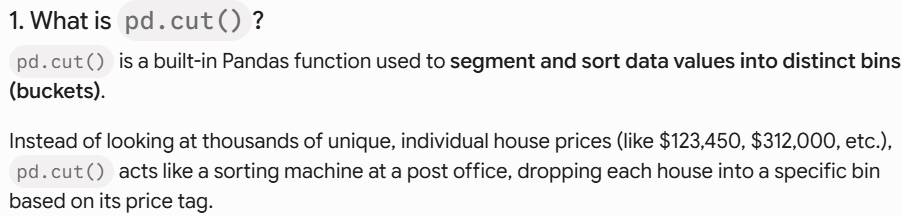
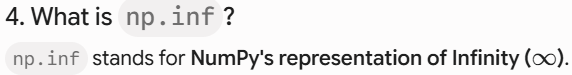

**Implementing Spatial Block-Group Validation**

In [646]:
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.model_selection import cross_validate
import pandas as pd
import numpy as np

# Create an artificial spatial regional cluster id by rounding coordinates down to one decimal unit.
# Houses sharing an identical rounded geo location map index values are clustered into the same spatial block group.
df["spatial_block_id"] = (df["latitude"].round(1).astype(str) + "_" + df["longitude"].round(1).astype(str))

# Re-extract full structural features arrays, ensuring we preserve our clustering keys.
X_spatial = df.drop(columns=[TARGET_COL])
y_spatial = df[TARGET_COL]

# Extract the block identities array sequence associated exclusively with our training sample data rows.
# To do this safely matching our original index, we run a train test split using our locked state rules.
X_train_sp, _, y_train_sp, _ = train_test_split(
    X_spatial, y_spatial, test_size=0.2, random_state=RANDOM_STATE
)

# Isolate spatial grouping key arrays completely from features tracking data arrays.
train_groups = X_train_sp["spatial_block_id"]
X_train_sp = X_train_sp.drop(columns=["spatial_block_id"])

# Instantiate GroupKFold validation matching our baseline fold capacity limits.
spatial_cv = GroupKFold(n_splits=5)

# Execute the cross-validation strategy using the best estimator from our previous grid search.
# We pass the 'groups' parameter explicitly so that data points from the same spatial block are never split across both the training and 
# validation sets simultaneously.
spatial_scores = cross_validate(
    grid_search_optimized.best_estimator_,
    X_train_sp,
    y_train_sp,
    groups=train_groups,
    cv=spatial_cv,
    scoring={"rmse": "neg_root_mean_squared_error"}, # FIXED: Wrapped metric in a dictionary to generate 'test_rmse'
    n_jobs=-1
)

print(f"Spatial/Grouped Cross-Validation Mean RMSE")
print(f"Robust Spatial CV RMSE: {-spatial_scores['test_rmse'].mean():.3f}")

Spatial/Grouped Cross-Validation Mean RMSE
Robust Spatial CV RMSE: 46945.133


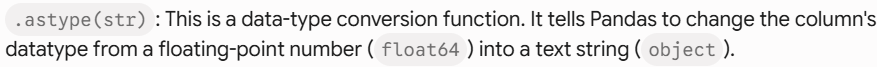
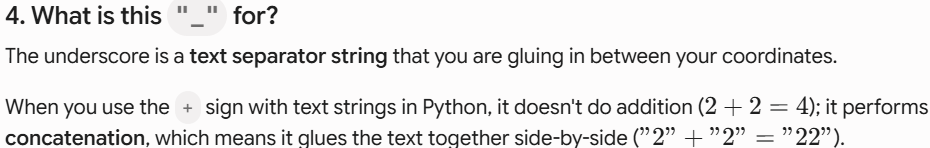
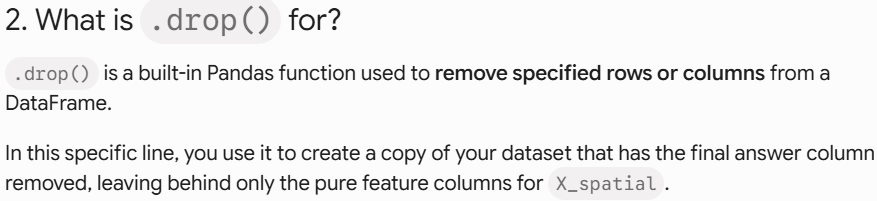
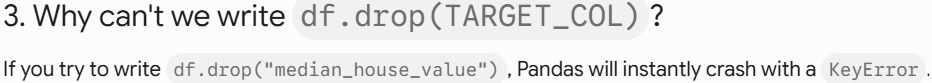
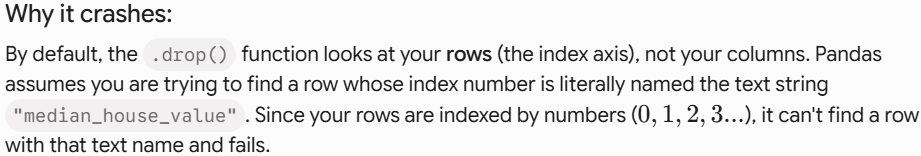
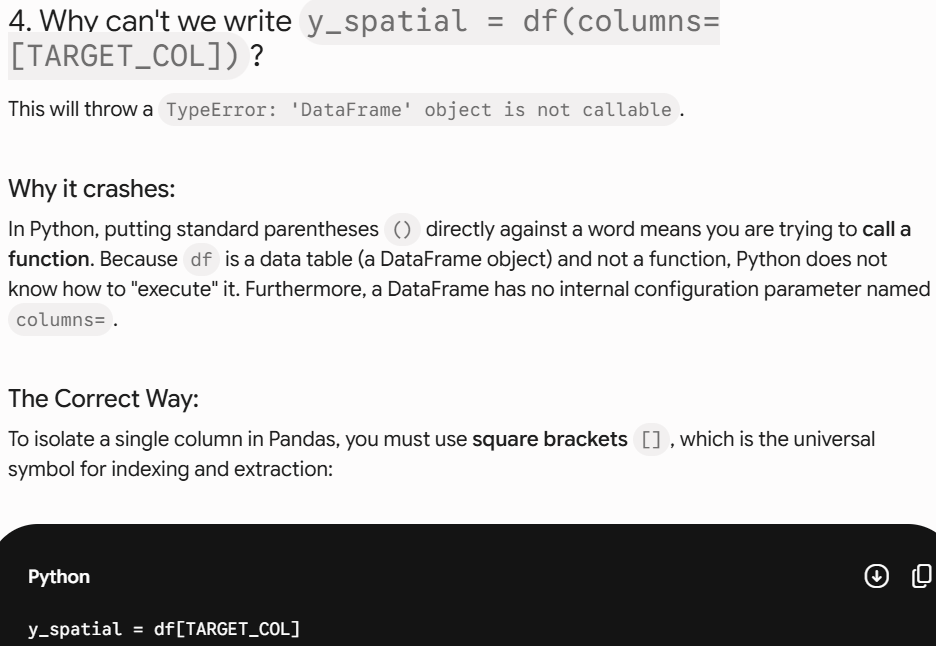
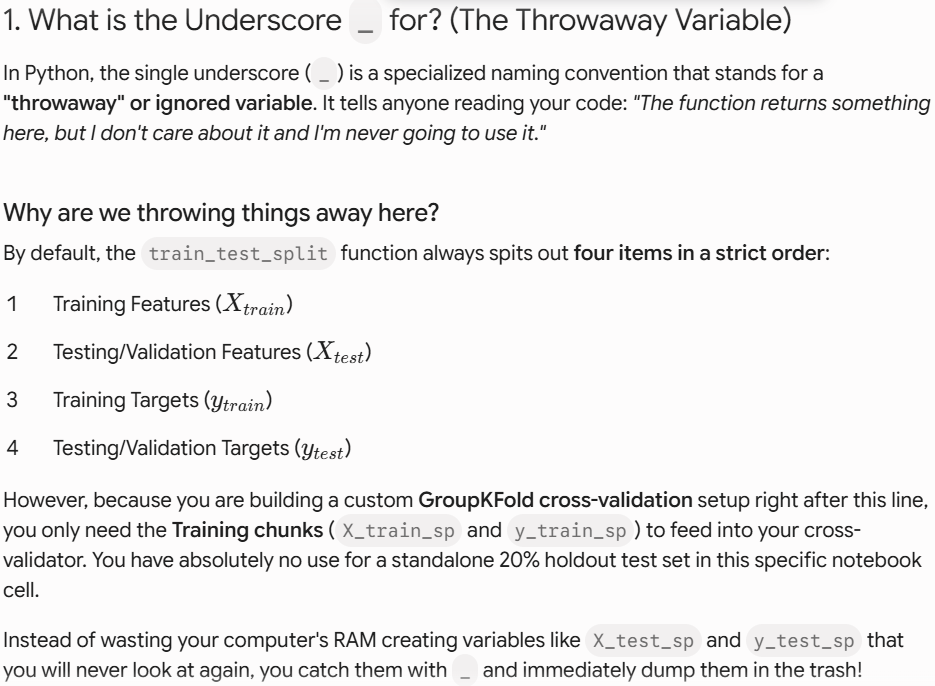
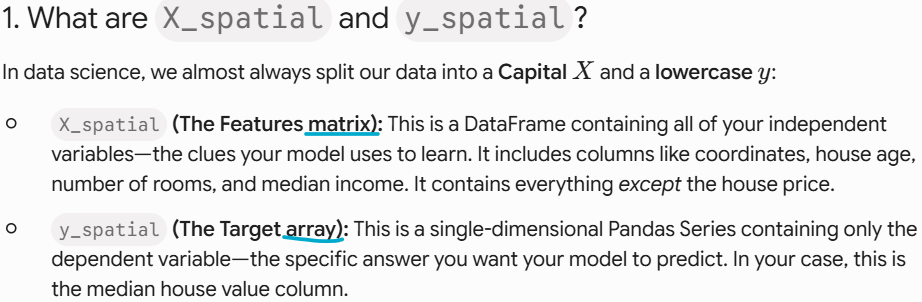
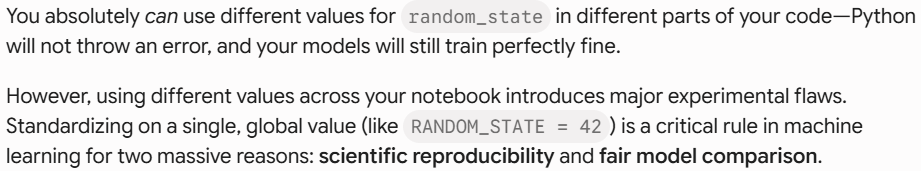
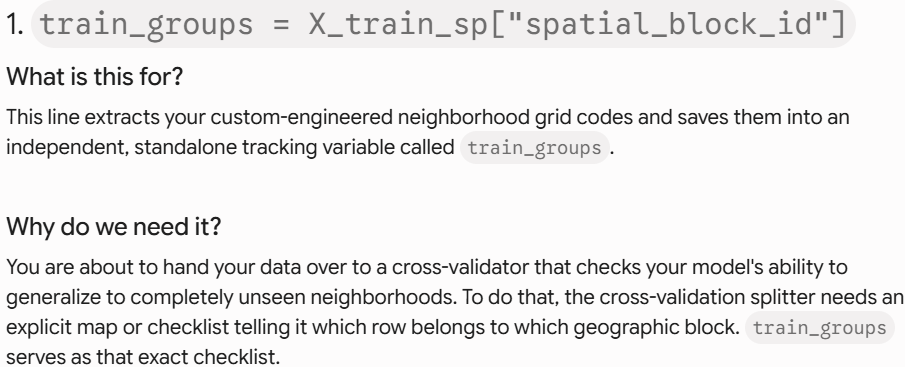
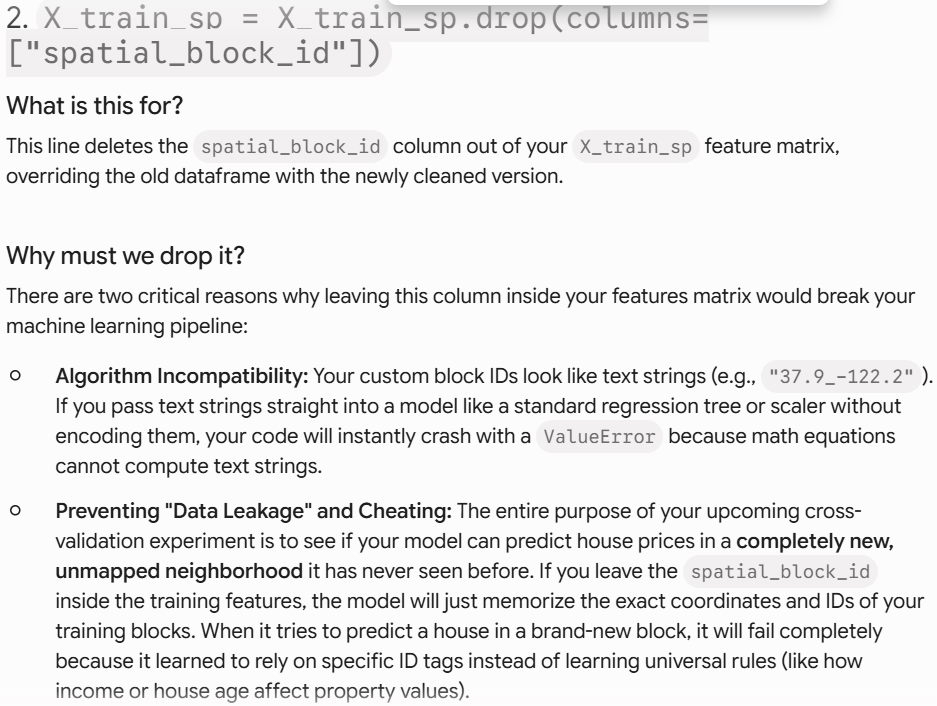
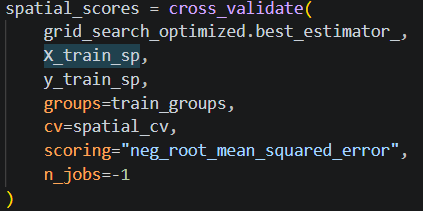
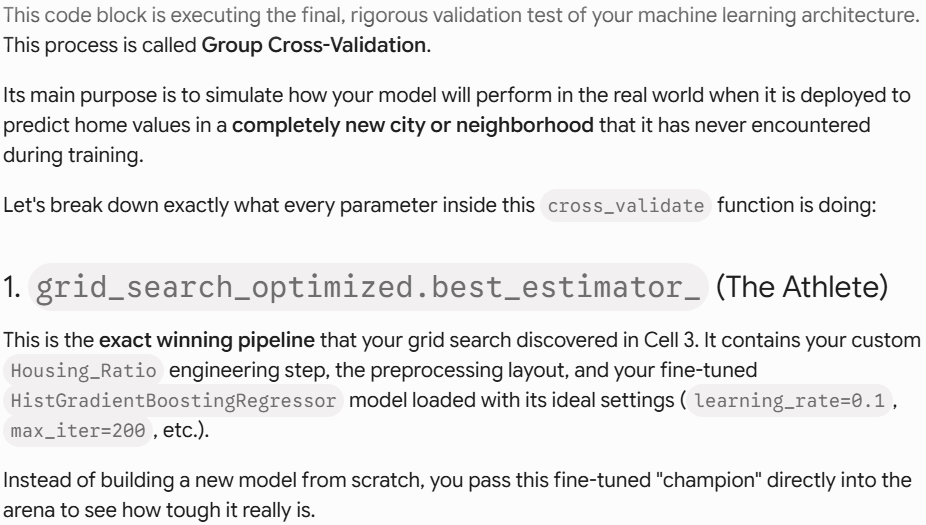
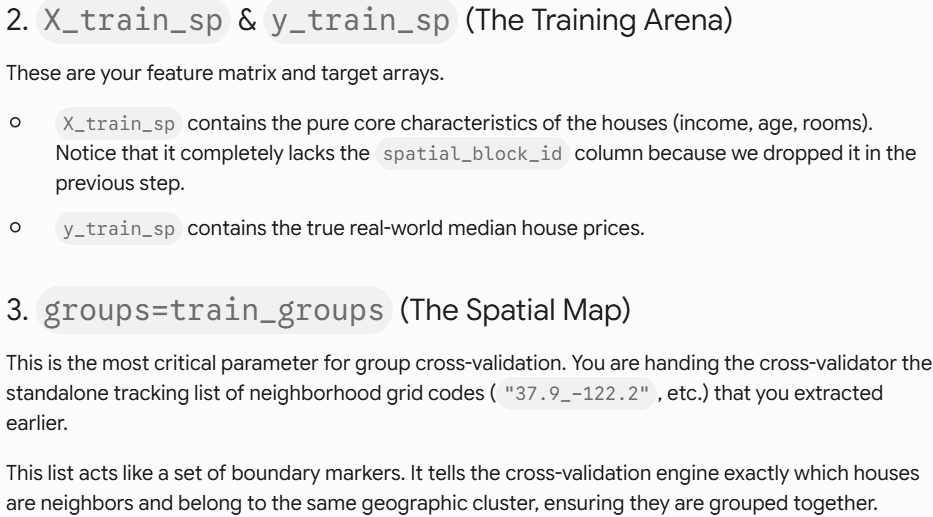
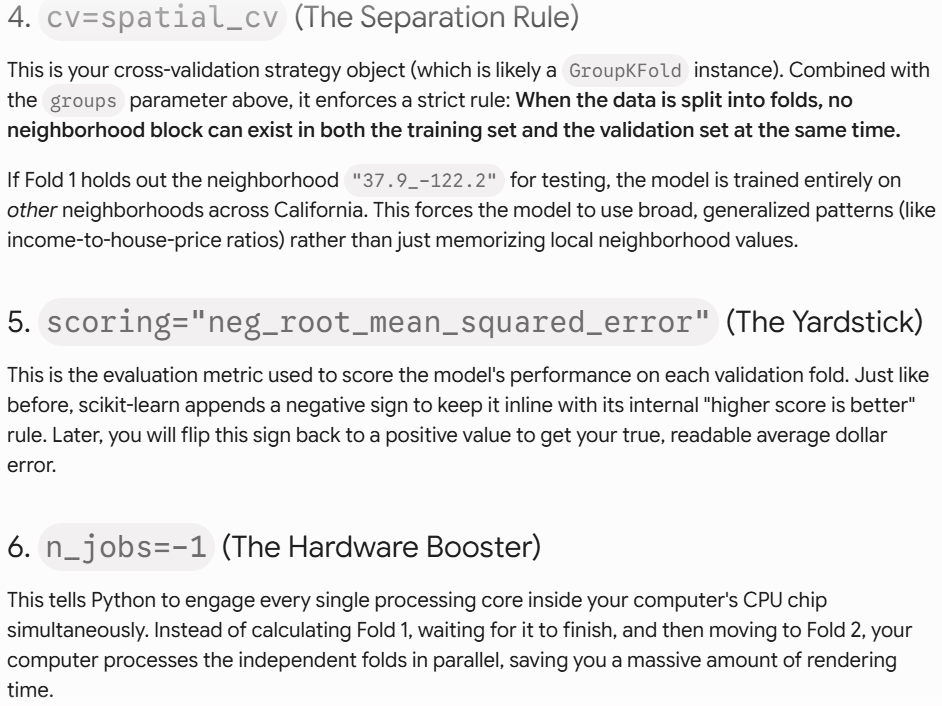
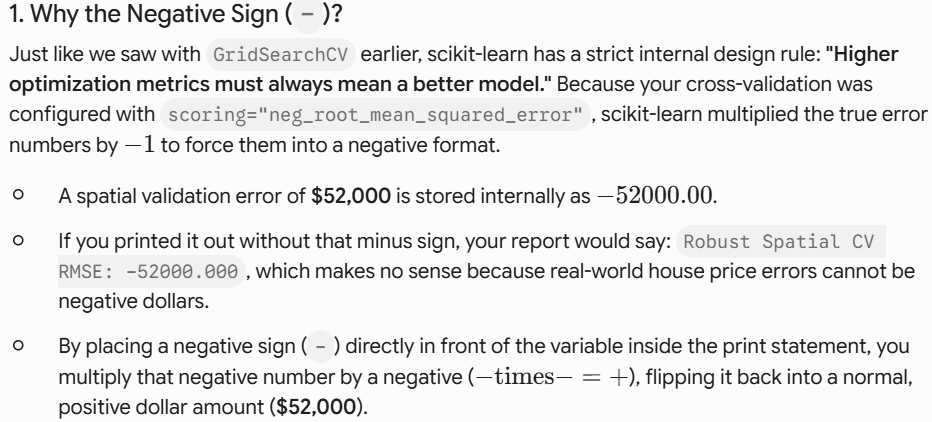
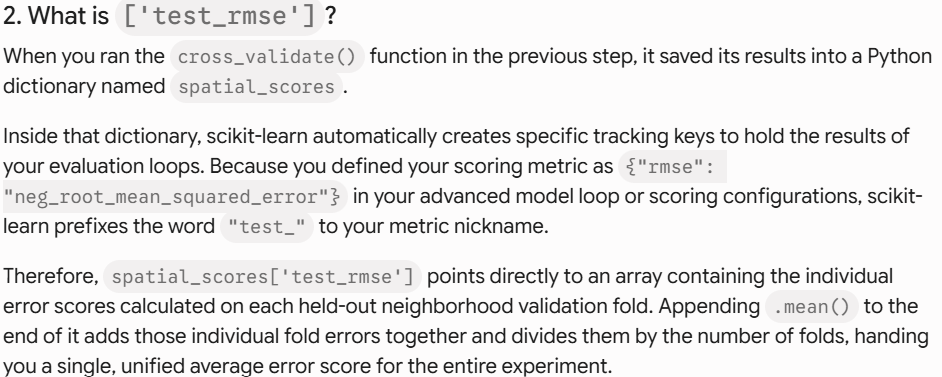


In [647]:
!jupyter nbconvert --to script 15_4_house_price_prediction.ipynb

[NbConvertApp] Converting notebook 15_4_house_price_prediction.ipynb to script
[NbConvertApp] Writing 87310 bytes to 15_4_house_price_prediction.py
